# ANALITICA DE DATOS CON INTELIGENCIA ARTIFICIAL

# ALGORITMOS GENETICOS

**Universidad de los Andes**

2025

---


Juan Carlos Vega, M.Sc.

# PREDICCION DEL PRECIO DE LA ELECTRICIDAD A PARTIR DE DEEP LEARNING

**Propósito y Funcionalidad**


El objetivo de este núcleo es comparar diferentes arquitecturas de **redes neuronales profundas** (+XGBoost) en la tarea de predecir el precio de la electricidad de la próxima hora utilizando los valores pasados del precio de la electricidad así como los de otras características relacionadas con la generación de energía y las condiciones meteorológicas. Además, el núcleo contiene una exploración y limpieza meticulosa de los datos, análisis de series temporales del precio de la electricidad y una ingeniería de características cuidadosa. Con más investigación y desarrollo (por ejemplo, como un modelo de pronóstico que se actualiza en tiempo real) un enfoque similar podría resultar útil para todos los interesados (compañías de energía eléctrica, inversores, etc.) involucrados en los mercados energéticos.


En el proyecto, comparé el rendimiento (utilizando el Error Cuadrático Medio Raíz como la métrica de rendimiento) de 5 arquitecturas diferentes (LSTM, LSTM apilado, CNN, CNN-LSTM y MLP Distribuido en el Tiempo) para pronósticos univariados y multivariados (es decir, usando solo los pasos de tiempo anteriores del precio de la electricidad vs. también usando otras características) utilizando un número diferente de pasos de tiempo anteriores como las características para los modelos (3, 10 y 25 pasos de tiempo anteriores para todas las características utilizadas).

En esta ANN particular, encontrarás una aplicación de todas las arquitecturas de aprendizaje profundo mencionadas anteriormente, así como dos enfoques más: la arquitectura Autocodificador y el regresor XGBoost. Además, en todas estas aplicaciones, utilizo los 25 pasos de tiempo anteriores de todas las características (pronóstico multivariado) que han sido extraídas o generadas, después de aplicar el Análisis de Componentes Principales (PCA). El optimizador Adam se utiliza en todas las arquitecturas de aprendizaje profundo y, para elegir su tasa de aprendizaje, originalmente realicé pruebas preliminares usando el callback del programador de tasa de aprendizaje comenzando con una tasa de aprendizaje igual a 0.01.

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import tensorflow as tf
import xgboost as xgb
import os
import warnings
from tensorflow.keras.layers import Dense, LSTM, Conv1D, MaxPooling1D, TimeDistributed, Flatten, Dropout, RepeatVector
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss, ccf
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from math import sqrt

%matplotlib inline

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [ ]:
warnings.simplefilter(action='ignore', category=(FutureWarning, UserWarning))

In [ ]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.4/87.4 kB 2.2 MB/s eta 0:00:00


In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score


In [ ]:
print(LabelEncoder.__doc__)

Encode target labels with value between 0 and n_classes-1.

This transformer should be used to encode target values, *i.e.* `y`, and
not the input `X`.

Read more in the :ref:`User Guide <preprocessing_targets>`.

.. versionadded:: 0.12

Attributes
----------
classes_ : ndarray of shape (n_classes,)
    Holds the label for each class.

See Also
--------
OrdinalEncoder : Encode categorical features using an ordinal encoding
    scheme.
OneHotEncoder : Encode categorical features as a one-hot numeric array.

Examples
--------
`LabelEncoder` can be used to normalize labels.

>>> from sklearn.preprocessing import LabelEncoder
>>> le = LabelEncoder()
>>> le.fit([1, 2, 2, 6])
LabelEncoder()
>>> le.classes_
array([1, 2, 6])
>>> le.transform([1, 1, 2, 6])
array([0, 0, 1, 2]...)
>>> le.inverse_transform([0, 0, 1, 2])
array([1, 1, 2, 6])

It can also be used to transform non-numerical labels (as long as they are
hashable and comparable) to numerical labels.

>>> le = LabelEncoder()
>>> le.fit(["

En este conjunto de datos, tenemos dos archivos .csv que contienen información horaria sobre la generación de electricidad y el clima en España para el período 2015-2019 (4 años). En particular:

**'weather_features.csv':** Contiene información horaria sobre las condiciones meteorológicas (por ejemplo, temperatura, velocidad del viento, humedad, precipitaciones, descripción cualitativa) de 5 ciudades principales en España (Madrid, Barcelona, Valencia, Sevilla y Bilbao).

**'energy_dataset.csv':** Contiene información horaria sobre la generación de energía en España. En particular, hay información (en MW) sobre la cantidad de electricidad generada por las diversas fuentes de energía (el gas fósil, el carbón duro fósil y la energía eólica dominan la red energética), así como sobre la carga total (demanda de energía) de la red nacional y el precio de la energía (€/MWh).
Nota: Dado que la generación de cada tipo de energía está en MW y la serie temporal contiene información horaria, el valor de cada celda representa MWh (megavatios hora).

La información que tenemos sobre el clima de 5 ciudades principales en España (destacadas por una estrella roja en el mapa a continuación) es probablemente más que suficiente para nuestro análisis, ya que su distribución geográfica cubre la mayor parte del territorio de España de manera uniforme. Además, es útil señalar que estas 5 ciudades solas comprenden aproximadamente 1/3 del total de la población de España.

In [ ]:
![Highlighted cities for which we have weather information](https://i.imgur.com/Hfb9vmq.png)

/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `[Highlighted cities for which we have weather information](https://i.imgur.com/Hfb9vmq.png)'


#**Leer los datasets**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df_weather = pd.read_csv(
    #'/content/drive/MyDrive/DIPLOMADO EPM/Datos/weather_features.csv'
    '/content/drive/MyDrive/SENSORES REMOTOS/weather_features.csv',
    parse_dates=['dt_iso']
)

df_energy = pd.read_csv(
    #'/content/drive/MyDrive/DIPLOMADO EPM/Datos/energy_dataset.csv'
    '/content/drive/MyDrive/SENSORES REMOTOS/energy_dataset.csv',
    parse_dates=['time']
)

**1.1. Datos de Energia**

In [ ]:
df_energy.head()

,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2015-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,...,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
1,2015-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,...,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2,2015-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,...,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48
3,2015-01-01 03:00:00+01:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,...,191.0,0.0,5238.0,2.0,NaN,5151.0,22642.0,21286.0,42.27,59.32
4,2015-01-01 04:00:00+01:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,...,189.0,0.0,4935.0,9.0,NaN,4861.0,21785.0,20264.0,38.41,56.04


In [ ]:
df_energy.describe()

,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,generation hydro pumped storage aggregated,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
count,35045.000000,35046.000000,35046.0,35046.000000,35046.000000,35045.000000,35046.0,35046.0,35046.0,0.0,...,35045.000000,35046.0,35046.000000,35064.000000,0.0,35064.000000,35064.000000,35028.000000,35064.000000,35064.000000
mean,383.513540,448.059208,0.0,5622.737488,4256.065742,298.319789,0.0,0.0,0.0,NaN,...,269.452133,0.0,5464.479769,1439.066735,NaN,5471.216689,28712.129962,28696.939905,49.874341,57.884023
std,85.353943,354.568590,0.0,2201.830478,1961.601013,52.520673,0.0,0.0,0.0,NaN,...,50.195536,0.0,3213.691587,1677.703355,NaN,3176.312853,4594.100854,4574.987950,14.618900,14.204083
min,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,NaN,...,0.000000,0.0,0.000000,0.000000,NaN,237.000000,18105.000000,18041.000000,2.060000,9.330000
25%,333.000000,0.000000,0.0,4126.000000,2527.000000,263.000000,0.0,0.0,0.0,NaN,...,240.000000,0.0,2933.000000,69.000000,NaN,2979.000000,24793.750000,24807.750000,41.490000,49.347500
50%,367.000000,509.000000,0.0,4969.000000,4474.000000,300.000000,0.0,0.0,0.0,NaN,...,279.000000,0.0,4849.000000,576.000000,NaN,4855.000000,28906.000000,28901.000000,50.520000,58.020000
75%,433.000000,757.000000,0.0,6429.000000,5838.750000,330.000000,0.0,0.0,0.0,NaN,...,310.000000,0.0,7398.000000,2636.000000,NaN,7353.000000,32263.250000,32192.000000,60.530000,68.010000
max,592.000000,999.000000,0.0,20034.000000,8359.000000,449.000000,0.0,0.0,0.0,NaN,...,357.000000,0.0,17436.000000,5836.000000,NaN,17430.000000,41390.000000,41015.000000,101.990000,116.800000


Eliminaremos todas las columnas que estén constituidas por ceros y NaNs, ya que no son utilizables. También eliminaremos las columnas que no se utilizarán en absoluto en nuestro análisis y que contienen pronósticos para el día siguiente de la carga total, la energía solar y la energía eólica.

In [ ]:
# Borrar columnas

df_energy = df_energy.drop(['generation fossil coal-derived gas','generation fossil oil shale',
                            'generation fossil peat', 'generation geothermal',
                            'generation hydro pumped storage aggregated', 'generation marine',
                            'generation wind offshore', 'forecast wind offshore eday ahead',
                            'total load forecast', 'forecast solar day ahead',
                            'forecast wind onshore day ahead'],
                            axis=1)

In [ ]:
df_energy.describe().round(2)

,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind onshore,total load actual,price day ahead,price actual
count,35045.00,35046.00,35046.00,35046.00,35045.00,35045.00,35045.00,35046.00,35047.00,35046.00,35046.00,35046.00,35045.00,35046.00,35028.00,35064.00,35064.00
mean,383.51,448.06,5622.74,4256.07,298.32,475.58,972.12,2605.11,6263.91,60.23,85.64,1432.67,269.45,5464.48,28696.94,49.87,57.88
std,85.35,354.57,2201.83,1961.60,52.52,792.41,400.78,1835.20,839.67,20.24,14.08,1680.12,50.20,3213.69,4574.99,14.62,14.20
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,18041.00,2.06,9.33
25%,333.00,0.00,4126.00,2527.00,263.00,0.00,637.00,1077.25,5760.00,53.00,73.00,71.00,240.00,2933.00,24807.75,41.49,49.35
50%,367.00,509.00,4969.00,4474.00,300.00,68.00,906.00,2164.00,6566.00,57.00,88.00,616.00,279.00,4849.00,28901.00,50.52,58.02
75%,433.00,757.00,6429.00,5838.75,330.00,616.00,1250.00,3757.00,7025.00,80.00,97.00,2578.00,310.00,7398.00,32192.00,60.53,68.01
max,592.00,999.00,20034.00,8359.00,449.00,4523.00,2000.00,9728.00,7117.00,106.00,119.00,5792.00,357.00,17436.00,41015.00,101.99,116.80


In [ ]:
df_energy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   time                                         35064 non-null  object 
 1   generation biomass                           35045 non-null  float64
 2   generation fossil brown coal/lignite         35046 non-null  float64
 3   generation fossil gas                        35046 non-null  float64
 4   generation fossil hard coal                  35046 non-null  float64
 5   generation fossil oil                        35045 non-null  float64
 6   generation hydro pumped storage consumption  35045 non-null  float64
 7   generation hydro run-of-river and poundage   35045 non-null  float64
 8   generation hydro water reservoir             35046 non-null  float64
 9   generation nuclear                           35047 non-null  float64
 10

In [ ]:
# Convertir tiempo a el formato datetime

df_energy['time'] = pd.to_datetime(df_energy['time'], utc=True, infer_datetime_format=True)
df_energy = df_energy.set_index('time')

In [ ]:
# Encontrar NaNs y valores duplicados en df_energy

print('There are {} missing values or NaNs in df_energy.'
      .format(df_energy.isnull().values.sum()))

temp_energy = df_energy.duplicated(keep='first').sum()

print('There are {} duplicate rows in df_energy based on all columns.'
      .format(temp_energy))

There are 292 missing values or NaNs in df_energy.
There are 0 duplicate rows in df_energy based on all columns.


In [ ]:
# Encontrar el numero de NaNs en cada columna

df_energy.isnull().sum(axis=0)

,0
generation biomass,19
generation fossil brown coal/lignite,18
generation fossil gas,18
generation fossil hard coal,18
generation fossil oil,19
generation hydro pumped storage consumption,19
generation hydro run-of-river and poundage,19
generation hydro water reservoir,18
generation nuclear,17
generation other,18


La mayoría de los valores nulos se pueden encontrar en la columna **'total load actual'**. Por lo tanto, es una buena idea visualizarla y ver qué podemos hacer. La buena noticia es que **no hay NaNs en la columna 'price actual'**, la cual utilizaremos como variable objetivo para entrenar nuestro modelo. Los números similares en valores nulos en las columnas que tienen que ver con el tipo de generación de energía probablemente indican que también aparecerán en las mismas filas. Primero definamos una función de gráfico que luego usaremos para visualizar la columna 'total load actual', así como otras columnas.

In [ ]:
# Definir una funcion para graficar los diferentes tipos de time-series

def plot_series(df=None, column=None, series=pd.Series([]),
                label=None, ylabel=None, title=None, start=0, end=None):
    """
  Trazar una serie temporal específica que ha sido cargada en un dataframe
  y que constituye una de sus columnas o es una serie de pandas personalizada
  creada por el usuario. El usuario puede definir ya sea el 'df' y la 'columna'
  o la 'serie' y, además, también puede definir la 'etiqueta', la
  'ylabel', el 'título', el 'inicio' y el 'final' del gráfico.
    """
    sns.set()
    fig, ax = plt.subplots(figsize=(30, 12))
    ax.set_xlabel('Time', fontsize=16)
    if column:
        ax.plot(df[column][start:end], label=label)
        ax.set_ylabel(ylabel, fontsize=16)
    if series.any():
        ax.plot(series, label=label)
        ax.set_ylabel(ylabel, fontsize=16)
    if label:
        ax.legend(fontsize=16)
    if title:
        ax.set_title(title, fontsize=24)
    ax.grid(True)
    return ax

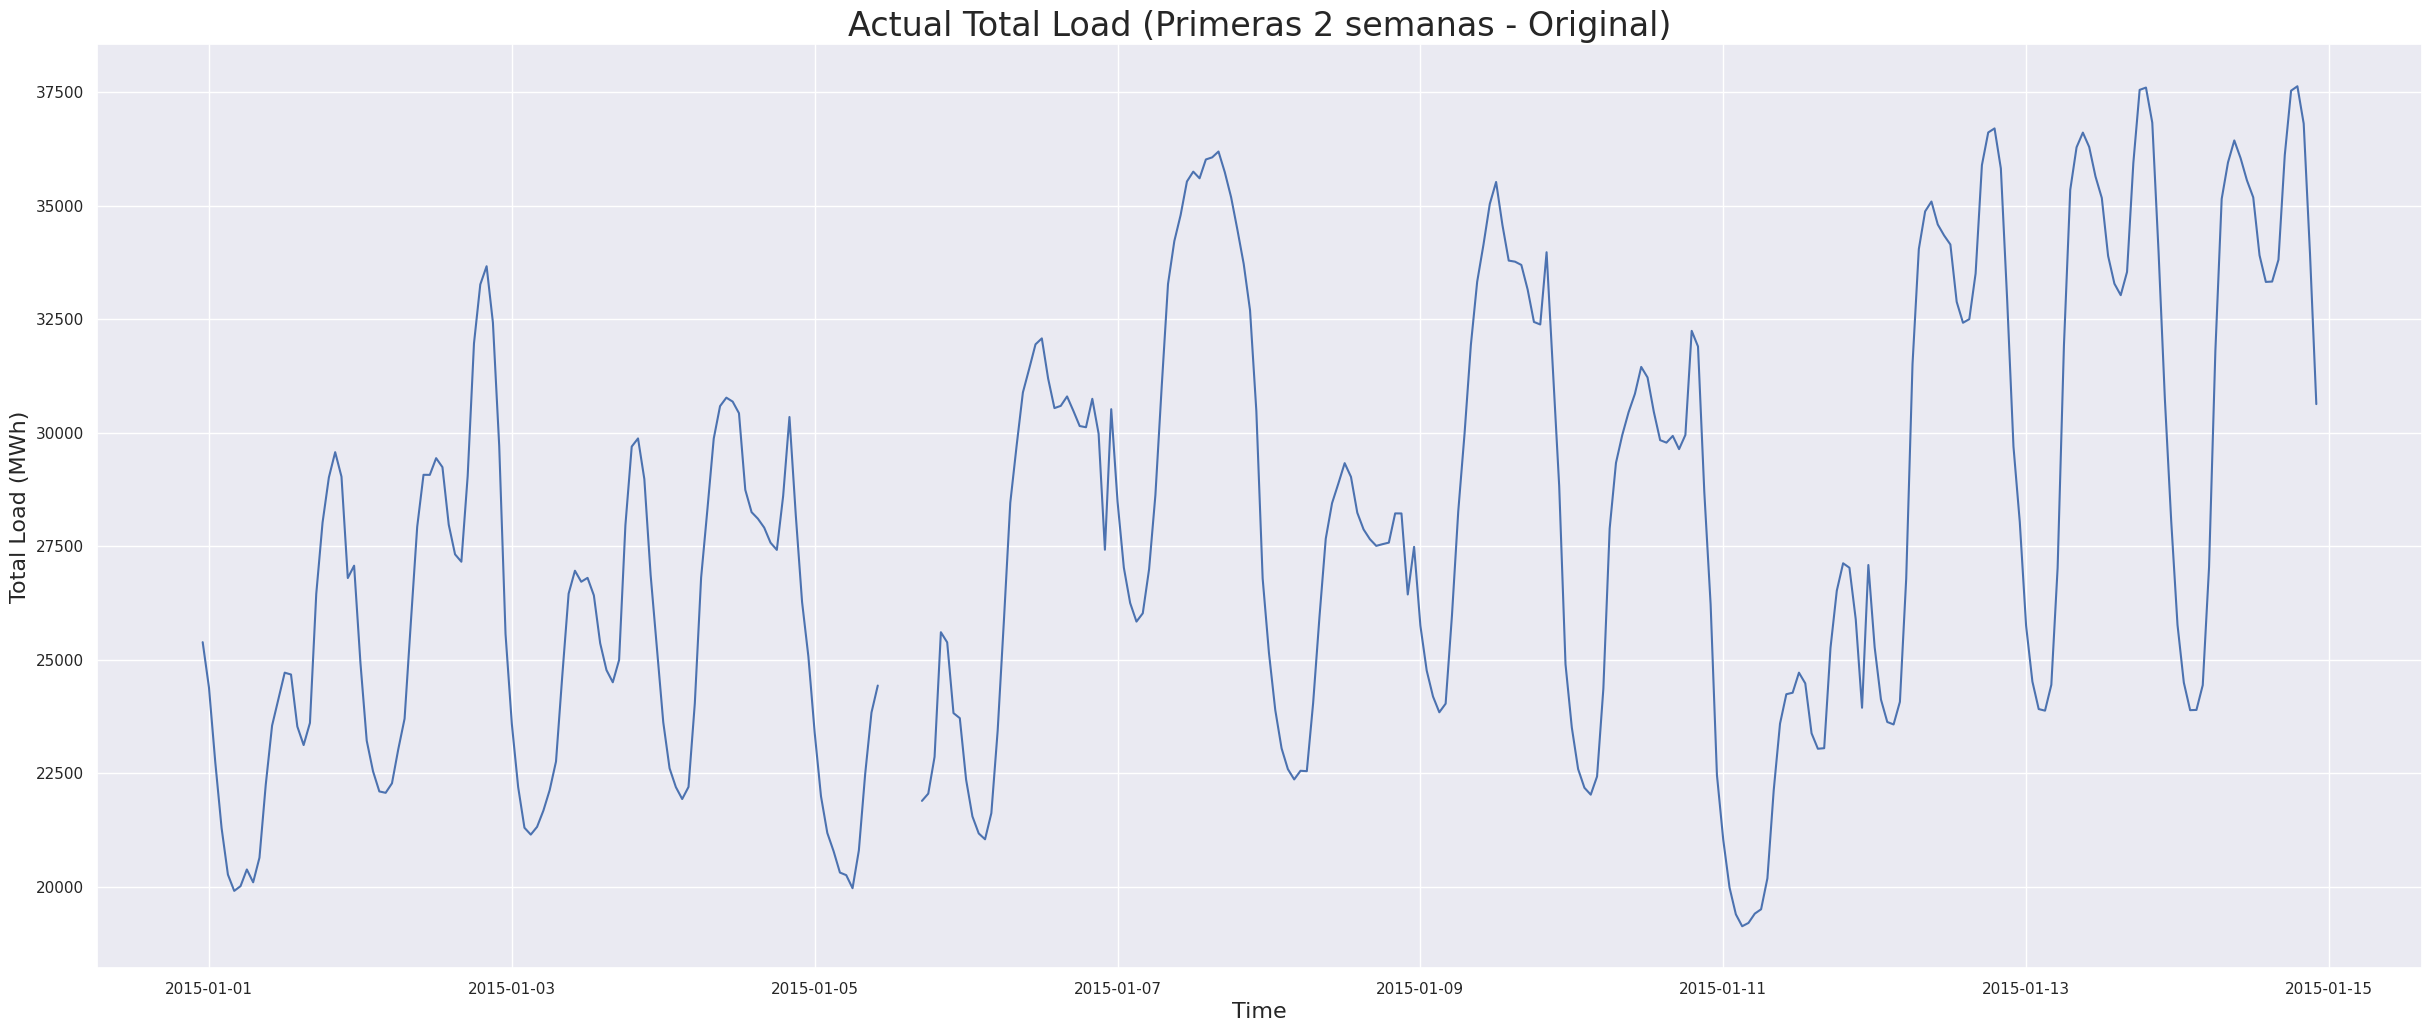

In [ ]:
# Zoom al gráfico de la carga total (real) por hora

ax = plot_series(df=df_energy, column='total load actual', ylabel='Total Load (MWh)',
                 title='Actual Total Load (Primeras 2 semanas - Original)', end=24*7*2)
plt.show()

Después de acercarnos a las primeras 2 semanas de la columna 'total load actual', ya podemos ver que hay valores nulos para algunas horas. Sin embargo, el número de los valores faltantes y el comportamiento de la serie indican que una interpolación llenaría los NaNs bastante bien. Investiguemos más a fondo si los valores nulos coinciden en las diferentes columnas. Mostremos las últimas cinco filas.

In [ ]:
# Llenar los NaNs con interpolacion

df_energy.interpolate(method='linear', limit_direction='forward', inplace=True, axis=0)

In [ ]:
# Desplegar las filas con valores nulos

df_energy[df_energy.isnull().any(axis=1)].tail()

,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind onshore,total load actual,price day ahead,price actual
time,,,,,,,,,,,,,,,,,



Parece que **df_energy** ha sido limpiado con éxito y está listo para su uso posterior como entrada en nuestro modelo. Los 1-4 ceros en las columnas que tienen que ver con la generación de energía por tipo no deberían preocuparnos mucho. El 'consumo de almacenamiento de energía hidroeléctrica bombeada' puede parecer sospechoso, pero debemos tener en cuenta que este tipo de energía solo se utiliza para el equilibrio de carga, siendo consumido cuando hay demandas de energía pico.

DESPUES DE INTERPOLACION

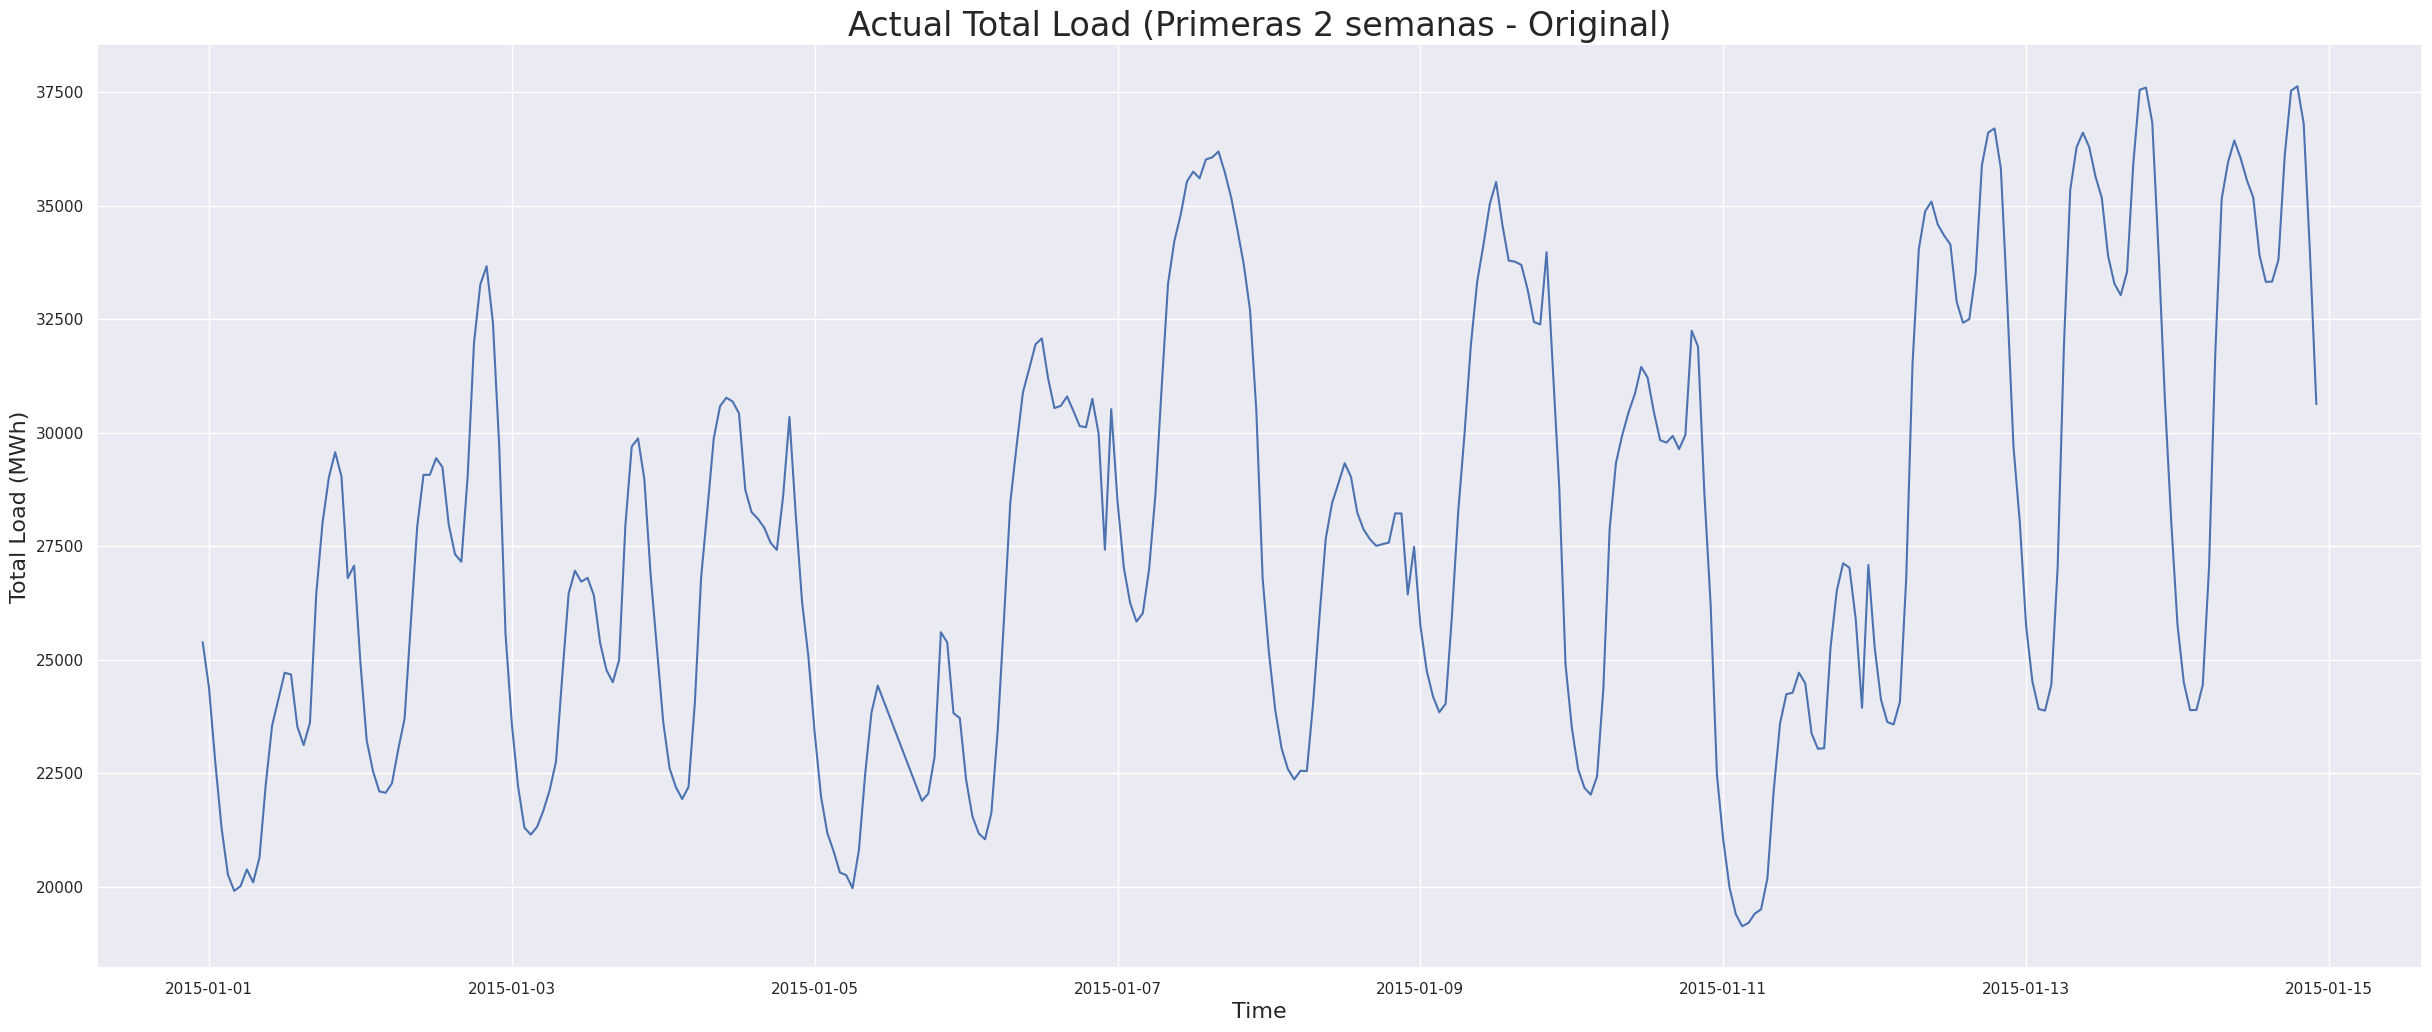

In [ ]:
# Zoom al gráfico de la carga total (real) por hora

ax = plot_series(df=df_energy, column='total load actual', ylabel='Total Load (MWh)',
                 title='Actual Total Load (Primeras 2 semanas - Original)', end=24*7*2)
plt.show()

**1.2. Datos Metereologicos**

In [ ]:
df_weather.head()

,dt_iso,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
0,2015-01-01 00:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
1,2015-01-01 01:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2,2015-01-01 02:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
3,2015-01-01 03:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
4,2015-01-01 04:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n


In [ ]:
df_weather.describe().round(2)

,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id
count,178396.00,178396.00,178396.00,178396.00,178396.00,178396.00,178396.00,178396.00,178396.00,178396.00,178396.00,178396.00
mean,289.62,288.33,291.09,1069.26,68.42,2.47,166.59,0.08,0.00,0.00,25.07,759.83
std,8.03,7.96,8.61,5969.63,21.90,2.10,116.61,0.40,0.01,0.22,30.77,108.73
min,262.24,262.24,262.24,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,200.00
25%,283.67,282.48,284.65,1013.00,53.00,1.00,55.00,0.00,0.00,0.00,0.00,800.00
50%,289.15,288.15,290.15,1018.00,72.00,2.00,177.00,0.00,0.00,0.00,20.00,800.00
75%,295.15,293.73,297.15,1022.00,87.00,4.00,270.00,0.00,0.00,0.00,40.00,801.00
max,315.60,315.15,321.15,1008371.00,100.00,133.00,360.00,12.00,2.32,21.50,100.00,804.00


Aquí, podemos ver que todas las columnas de **df_weather** tienen el mismo número de filas; sin embargo, todavía tenemos que verificar cuál es el caso para cada ciudad individualmente. Debemos notar que las temperaturas están en Kelvin. Lo más importante a notar es que hay algunos problemas y valores atípicos. En particular:

Hay al menos un valor atípico en la columna **'pressure'** ya que el valor máximo es 1,008,371 hPa o aproximadamente 100 MPa, lo cual es aproximadamente la presión en el fondo de la Fosa de las Marianas, unos 11 km por debajo de la superficie del océano [2]. Esto no puede ser el caso aquí.

Hay al menos un valor atípico en la columna **'wind_speed'** ya que el valor máximo es 133 m/s. Esta medición está cerca de la velocidad del viento más rápida jamás registrada en la Tierra, causada por el tornado Bridge Creek–Moore de 1999 [3], un tornado F5 (la intensidad más grande de la escala de Fujita) [4]. Un tornado de tal intensidad no ha sido registrado en España [5] y esperemos que no ocurra en el futuro también.

La columna **'rain_3h'** se supone que proporciona información sobre la precipitación (es decir, lluvia) de las últimas 3 horas en mm. Dado que la columna **'rain_1h' **se supone que proporciona la misma información pero solo sobre la última hora, sería lógico asumir que su media sería menor que la de 'rain_3h'. Sin embargo, este no es el caso en la descripción estadística anterior. Por lo tanto, sería una buena idea examinar más a fondo esas columnas.

In [ ]:
# Imprimir el tipo de cada variable en df_weather

df_weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178396 entries, 0 to 178395
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   dt_iso               178396 non-null  object 
 1   city_name            178396 non-null  object 
 2   temp                 178396 non-null  float64
 3   temp_min             178396 non-null  float64
 4   temp_max             178396 non-null  float64
 5   pressure             178396 non-null  int64  
 6   humidity             178396 non-null  int64  
 7   wind_speed           178396 non-null  int64  
 8   wind_deg             178396 non-null  int64  
 9   rain_1h              178396 non-null  float64
 10  rain_3h              178396 non-null  float64
 11  snow_3h              178396 non-null  float64
 12  clouds_all           178396 non-null  int64  
 13  weather_id           178396 non-null  int64  
 14  weather_main         178396 non-null  object 
 15  weather_descripti

In [ ]:
def df_convert_dtypes(df, convert_from, convert_to):
    cols = df.select_dtypes(include=[convert_from]).columns
    for col in cols:
        df[col] = df[col].values.astype(convert_to)
    return df

In [ ]:
# Convertir columnas con int64 a float64

df_weather = df_convert_dtypes(df_weather, np.int64, np.float64)

In [ ]:
# Convertir dt_iso a datetime

df_weather['time'] = pd.to_datetime(df_weather['dt_iso'], utc=True, infer_datetime_format=True)
df_weather = df_weather.drop(['dt_iso'], axis=1)
df_weather = df_weather.set_index('time')

Tenemos que dividir el conjunto de datos **df_weather** en 5 conjuntos de datos, uno para cada ciudad diferente **(Madrid, Barcelona, Bilbao, Sevilla y Valencia).** Pero primero, veamos los valores promedio para cada columna, agrupados por cada ciudad (nota que el promedio de **'weather_id'** no tiene ningún significado en absoluto).

In [ ]:
# mean_weather_by_city = df_weather.groupby('city_name').mean().select_dtypes(include=np.number)

numeric_df_weather = df_weather[['city_name'] + df_weather.select_dtypes(include=np.number).columns.tolist()]
mean_weather_by_city = numeric_df_weather.groupby('city_name').mean()

mean_weather_by_city

,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id
city_name,,,,,,,,,,,,
Barcelona,289.867178,288.615102,291.039356,1287.211356,73.830710,2.782740,187.664243,0.108487,0.000331,0.000000,22.714693,764.831622
Bilbao,286.443451,284.989988,288.090330,1017.483858,78.731006,1.958305,159.908938,0.119156,0.001057,0.024048,43.438712,727.320157
Madrid,288.277131,287.051835,289.371963,1011.781115,58.725331,2.433807,173.363906,0.043301,0.000133,0.000030,20.661334,769.420859
Seville,293.166541,291.259597,296.001726,1018.536990,63.780516,2.482717,151.885809,0.041136,0.000182,0.000000,14.165070,773.517511
Valencia,290.783954,290.225644,291.357900,1015.979381,65.093971,2.692477,160.801648,0.034458,0.000227,0.000154,20.740475,782.171800


In [ ]:
# Encontrar NaNs y duplicados en df_weather

print('There are {} missing values or NaNs in df_weather.'
      .format(df_weather.isnull().values.sum()))

temp_weather = df_weather.duplicated(keep='first').sum()

print('There are {} duplicate rows in df_weather based on all columns.'
      .format(temp_weather))

There are 0 missing values or NaNs in df_weather.
There are 8587 duplicate rows in df_weather based on all columns.


Parece que **df_weather** tiene muchos valores duplicados. Sin embargo, el método anterior también puede mostrarnos filas que tienen exactamente los mismos valores. Esto no es lo que estamos buscando. Lo que queremos asegurar es que no haya filas de índice duplicadas, es decir, que no tengamos múltiples filas para la misma hora exacta. Por supuesto, también tenemos que asegurarnos de que estos duplicados conciernen a cada ciudad individual. Dado que **df_weather** contiene información sobre 5 ciudades diferentes, es muy útil mostrar el número de observaciones para cada una y compararlo con el tamaño de **df_energy**.

In [ ]:
# Graficas el numero de filas x cada dataframe

print('There are {} observations in df_energy.'.format(df_energy.shape[0]))

cities = df_weather['city_name'].unique()
grouped_weather = df_weather.groupby('city_name')

for city in cities:
    print('There are {} observations in df_weather'
          .format(grouped_weather.get_group('{}'.format(city)).shape[0]),
          'about city: {}.'.format(city))

There are 35064 observations in df_energy.
There are 35064 observations in df_weather about city: Valencia.
There are 35064 observations in df_weather about city: Madrid.
There are 35064 observations in df_weather about city: Bilbao.
There are 35064 observations in df_weather about city:  Barcelona.
There are 35064 observations in df_weather about city: Seville.



Como podemos ver, los dos dataframes (**df_energy y df_weather)** aún no pueden combinarse. Hay muchos duplicados para cada ciudad en **df_weather** y deberíamos eliminarlos y ver si su número de filas coincide.

Hacemos esto restableciendo el índice, manteniendo solo las primeras filas que tienen los mismos valores de **'time'** y **'city_name'** y luego volviendo a establecer **'time'** como el índice. Para una investigación más profunda del conjunto de datos, creamos también un segundo dataframe, **df_weather_2** en el que hacemos el mismo procedimiento, pero mantenemos solo las últimas filas que tienen los mismos valores de **'time'** y **'city_name'**.

In [ ]:
# Crear df_weather_2 y borrar filas duplicadas en df_weather

df_weather_2 = df_weather.reset_index().drop_duplicates(subset=['time', 'city_name'],
                                                        keep='last').set_index('time')

df_weather = df_weather.reset_index().drop_duplicates(subset=['time', 'city_name'],
                                                      keep='first').set_index('time')

In [ ]:
# Display the number of rows in each dataframe again

print('There are {} observations in df_energy.'.format(df_energy.shape[0]))

cities = df_weather['city_name'].unique()
grouped_weather2 = df_weather2.groupby('city_name')

for city in cities:
    print('There are {} observations in df_weather'
          .format(grouped_weather2.get_group('{}'.format(city)).shape[0]),
          'about city: {}.'.format(city))

There are 35064 observations in df_energy.
There are 35064 observations in df_weather about city: Valencia.
There are 35064 observations in df_weather about city: Madrid.
There are 35064 observations in df_weather about city: Bilbao.
There are 35064 observations in df_weather about city:  Barcelona.
There are 35064 observations in df_weather about city: Seville.


In [ ]:
# Display the number of rows in each dataframe again

print('There are {} observations in df_energy.'.format(df_energy.shape[0]))

grouped_weather = df_weather.groupby('city_name')

for city in cities:
    print('There are {} observations in df_weather'
          .format(grouped_weather.get_group('{}'.format(city)).shape[0]),
          'about city: {}.'.format(city))

There are 35064 observations in df_energy.
There are 35064 observations in df_weather about city: Valencia.
There are 35064 observations in df_weather about city: Madrid.
There are 35064 observations in df_weather about city: Bilbao.
There are 35064 observations in df_weather about city:  Barcelona.
There are 35064 observations in df_weather about city: Seville.


La columna **'weather_icon'** es irrelevante para nuestro análisis, así que la eliminaremos. Además, las columnas **'weather_main'** y **'weather_description'** contienen aproximadamente la misma información que la columna **'weather_id'**; la información concierne a una descripción cualitativa del clima en la hora dada. Así que trabajaremos solo con una de ellas. Sin embargo, para tomar una decisión, tenemos que verificar los valores únicos así como la consistencia de cada columna.

In [ ]:
# Despleguar todos los valores unicos en la columna 'weather_description'

weather_description_unique = df_weather['weather_description'].unique()
weather_description_unique

array(['sky is clear', 'few clouds', 'scattered clouds', 'broken clouds',
       'overcast clouds', 'light rain', 'moderate rain',
       'heavy intensity rain', 'mist', 'heavy intensity shower rain',
       'shower rain', 'very heavy rain', 'thunderstorm with heavy rain',
       'thunderstorm with light rain', 'proximity thunderstorm',
       'thunderstorm', 'light intensity shower rain',
       'light intensity drizzle', 'thunderstorm with rain', 'fog',
       'smoke', 'drizzle', 'heavy intensity drizzle', 'haze',
       'proximity shower rain', 'light snow', 'rain and snow',
       'light rain and snow', 'snow', 'sleet', 'rain and drizzle',
       'light intensity drizzle rain', 'light shower snow',
       'proximity moderate rain', 'ragged shower rain', 'heavy snow',
       'sand dust whirls', 'proximity drizzle', 'dust',
       'light thunderstorm', 'squalls'], dtype=object)

In [ ]:
# Despleguar todos los valores unicos en la columna 'weather_main'

weather_main_unique = df_weather['weather_main'].unique()
weather_main_unique

array(['clear', 'clouds', 'rain', 'mist', 'thunderstorm', 'drizzle',
       'fog', 'smoke', 'haze', 'snow', 'dust', 'squall'], dtype=object)

In [ ]:
# Despleguar todos los valores unicos en la columna 'weather_id'

weather_id_unique = df_weather['weather_id'].unique()
weather_id_unique

array([800., 801., 802., 803., 804., 500., 501., 502., 701., 522., 521.,
       503., 202., 200., 211., 520., 300., 201., 741., 711., 301., 302.,
       721., 600., 616., 615., 601., 611., 311., 310., 620., 531., 602.,
       731., 761., 210., 771.])


Podemos ver que en términos de descripción cualitativa, la columna **'weather_main'** parece contener la información menos detallada -o "más pobre"-, mientras que **'weather_id'** y **'weather_description'** tienen información más compleja y aproximadamente el mismo número de valores únicos.

Sin embargo, también es útil **verificar la consistencia de la información en cada columna**. Dado que nuestro conjunto de datos contenía filas duplicadas y utilizamos dos métodos diferentes para limpiarlo, una muy buena manera de verificar la consistencia de los datos en estas tres columnas sería comparar los dos dataframes limpios, df_weather y df_weather_2. Para hacer esto, **empleamos la métrica R²** ("R cuadrado" o "coeficiente de determinación"), después de codificar 'weather_description' y 'weather_main' de cadenas a etiquetas numéricas.

In [ ]:
# Borrar columnas con informacion metereologica cualitativa
df_weather = df_weather.drop(['weather_main', 'weather_id',
                              'weather_description', 'weather_icon'], axis=1)

In [ ]:
# Display the number of duplicates in df_weather

temp_weather = df_weather.reset_index().duplicated(subset=['time', 'city_name'],
                                                   keep='first').sum()
print('There are {} duplicate rows in df_weather ' \
      'based on all columns except "time" and "city_name".'.format(temp_weather))

There are 0 duplicate rows in df_weather based on all columns except "time" and "city_name".



Antes de proceder al siguiente paso, es decir, **combinar df_energy y df_weather**, también queremos tratar los valores atípicos que encontramos anteriormente en **'pressure'** y **'wind_speed'**.

Visualizaremos los valores atípicos en estas columnas usando **boxplot**, cambiaremos sus valores a NaNs y luego usaremos una interpolación lineal para reemplazar sus valores.

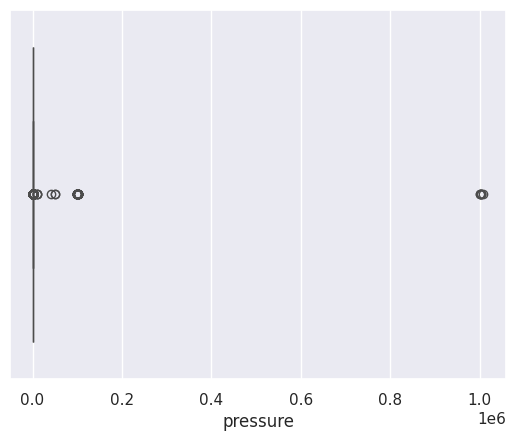

In [ ]:
# Chequear x outliers en la columna 'pressure'

sns.boxplot(x=df_weather['pressure'])
plt.show()

In [ ]:
# Display the number of rows in each dataframe again

print('There are {} observations in df_energy.'.format(df_energy.shape[0]))

grouped_weather = df_weather.groupby('city_name')

for city in cities:
    print('There are {} observations in df_weather'
          .format(grouped_weather.get_group('{}'.format(city)).shape[0]),
          'about city: {}.'.format(city))

There are 35064 observations in df_energy.
There are 35064 observations in df_weather about city: Valencia.
There are 35064 observations in df_weather about city: Madrid.
There are 35064 observations in df_weather about city: Bilbao.
There are 35064 observations in df_weather about city:  Barcelona.
There are 35064 observations in df_weather about city: Seville.


Incluso una presión de aproximadamente 100,000 HPa o 10 MPa, que es claramente visible en la figura anterior, corresponde a una cantidad mayor que la presión atmosférica de **Venus**. Para estar seguros, estableceremos como **NaN** cada valor en la columna **'pressure'** que sea **superior a 1051 hPa**, que está justo por encima de la presión atmosférica más alta jamás registrada en la península Ibérica.

Aunque los valores atípicos por el lado bajo no son visibles en el boxplot anterior, es una buena idea también reemplazar los valores que sean inferiores a 931 hPa, es decir, la presión atmosférica más baja jamás registrada en la península Ibérica.

In [ ]:
# Reemplazar outliers en 'pressure' con NaNs

df_weather.loc[df_weather.pressure > 1051, 'pressure'] = np.nan

In [ ]:
# Display the number of rows in each dataframe again

print('There are {} observations in df_energy.'.format(df_energy.shape[0]))

grouped_weather = df_weather.groupby('city_name')

for city in cities:
    print('There are {} observations in df_weather'
          .format(grouped_weather.get_group('{}'.format(city)).shape[0]),
          'about city: {}.'.format(city))

There are 35064 observations in df_energy.
There are 35064 observations in df_weather about city: Valencia.
There are 35064 observations in df_weather about city: Madrid.
There are 35064 observations in df_weather about city: Bilbao.
There are 35064 observations in df_weather about city:  Barcelona.
There are 35064 observations in df_weather about city: Seville.


In [ ]:
# Interpolar los valores nulos

df_weather.interpolate(method='linear', limit_direction='forward', inplace=True, axis=0)

**1.3. Combinar datasets**

Variemos un poco el ejercicio. No solo vamos a combinar los dataframes, vamos a reemplazar las ciudades por 5 ciudades colombianas y trabajaremos el ejercicio como si fueran datos nacionales.

In [ ]:
# Dividir df_weather en DataFrames separados para cada ciudad específica
df_Medellin = df_weather[df_weather['city_name'] == ' Barcelona']
df_Bogota = df_weather[df_weather['city_name'] == 'Bilbao']
df_Bucaramanga = df_weather[df_weather['city_name'] == 'Madrid']
df_Cali = df_weather[df_weather['city_name'] == 'Seville']
df_Cartagena = df_weather[df_weather['city_name'] == 'Valencia']

# Verificar que cada DataFrame contenga solo datos de su respectiva ciudad
print(f"Medellin: {df_Medellin['city_name'].unique()}")
print(f"Bogota: {df_Bogota['city_name'].unique()}")
print(f"Bucaramanga: {df_Bucaramanga['city_name'].unique()}")
print(f"Cali: {df_Cali['city_name'].unique()}")
print(f"Cartagena: {df_Cartagena['city_name'].unique()}")


Medellin: [' Barcelona']
Bogota: ['Bilbao']
Bucaramanga: ['Madrid']
Cali: ['Seville']
Cartagena: ['Valencia']


In [ ]:
# Merge all dataframes into the final dataframe

# Asumiendo que df_energy ya está definido y quieres combinarlo con los datos meteorológicos de las ciudades

# Lista de los DataFrames de las ciudades y sus respectivos nombres
city_dfs = [
    (df_Medellin, "Medellin"),
    (df_Bogota, "Bogota"),
    (df_Bucaramanga, "Bucaramanga"),
    (df_Cali, "Cali"),
    (df_Cartagena, "Cartagena")
]

df_final = df_energy.copy()  # Crea una copia de df_energy para mantener el original intacto

for df, city_name in city_dfs:
    # Añade un sufijo a cada columna del DataFrame de la ciudad, excepto 'time' y 'city_name'
    df_city = df.drop(columns=['city_name']).add_suffix(f'_{city_name}')

    # Fusiona el DataFrame de la ciudad con df_final basado en la columna 'time'
    df_final = df_final.merge(df_city, on='time', how='outer')

# Verifica las columnas del DataFrame final
print(df_final.columns)


Index(['generation biomass', 'generation fossil brown coal/lignite',
       'generation fossil gas', 'generation fossil hard coal',
       'generation fossil oil', 'generation hydro pumped storage consumption',
       'generation hydro run-of-river and poundage',
       'generation hydro water reservoir', 'generation nuclear',
       'generation other', 'generation other renewable', 'generation solar',
       'generation waste', 'generation wind onshore', 'total load actual',
       'price day ahead', 'price actual', 'temp_Medellin', 'temp_min_Medellin',
       'temp_max_Medellin', 'pressure_Medellin', 'humidity_Medellin',
       'wind_speed_Medellin', 'wind_deg_Medellin', 'rain_1h_Medellin',
       'rain_3h_Medellin', 'snow_3h_Medellin', 'clouds_all_Medellin',
       'temp_Bogota', 'temp_min_Bogota', 'temp_max_Bogota', 'pressure_Bogota',
       'humidity_Bogota', 'wind_speed_Bogota', 'wind_deg_Bogota',
       'rain_1h_Bogota', 'rain_3h_Bogota', 'snow_3h_Bogota',
       'clouds_all_Bog

In [ ]:
print(df_final.shape)
print(df_final.columns)

(35064, 72)
Index(['generation biomass', 'generation fossil brown coal/lignite',
       'generation fossil gas', 'generation fossil hard coal',
       'generation fossil oil', 'generation hydro pumped storage consumption',
       'generation hydro run-of-river and poundage',
       'generation hydro water reservoir', 'generation nuclear',
       'generation other', 'generation other renewable', 'generation solar',
       'generation waste', 'generation wind onshore', 'total load actual',
       'price day ahead', 'price actual', 'temp_Medellin', 'temp_min_Medellin',
       'temp_max_Medellin', 'pressure_Medellin', 'humidity_Medellin',
       'wind_speed_Medellin', 'wind_deg_Medellin', 'rain_1h_Medellin',
       'rain_3h_Medellin', 'snow_3h_Medellin', 'clouds_all_Medellin',
       'temp_Bogota', 'temp_min_Bogota', 'temp_max_Bogota', 'pressure_Bogota',
       'humidity_Bogota', 'wind_speed_Bogota', 'wind_deg_Bogota',
       'rain_1h_Bogota', 'rain_3h_Bogota', 'snow_3h_Bogota',
       'cl

In [ ]:
# Muestre el numero de NaNs y duplicados en el dataframe final

print('There are {} missing values or NaNs in df_final.'
      .format(df_final.isnull().values.sum()))

temp_final = df_final.duplicated(keep='first').sum()

print('\nThere are {} duplicate rows in df_energy based on all columns.'
      .format(temp_final))

There are 0 missing values or NaNs in df_final.

There are 0 duplicate rows in df_energy based on all columns.


# 2. VISUALIZACIONES Y ANALISIS DE SERIES DE TIEMPO

**2.1. Algunos tipos de visualización**

Antes que nada, revisaremos las columnas **'rain_1h' y 'rain_3h'** para una ciudad específica.

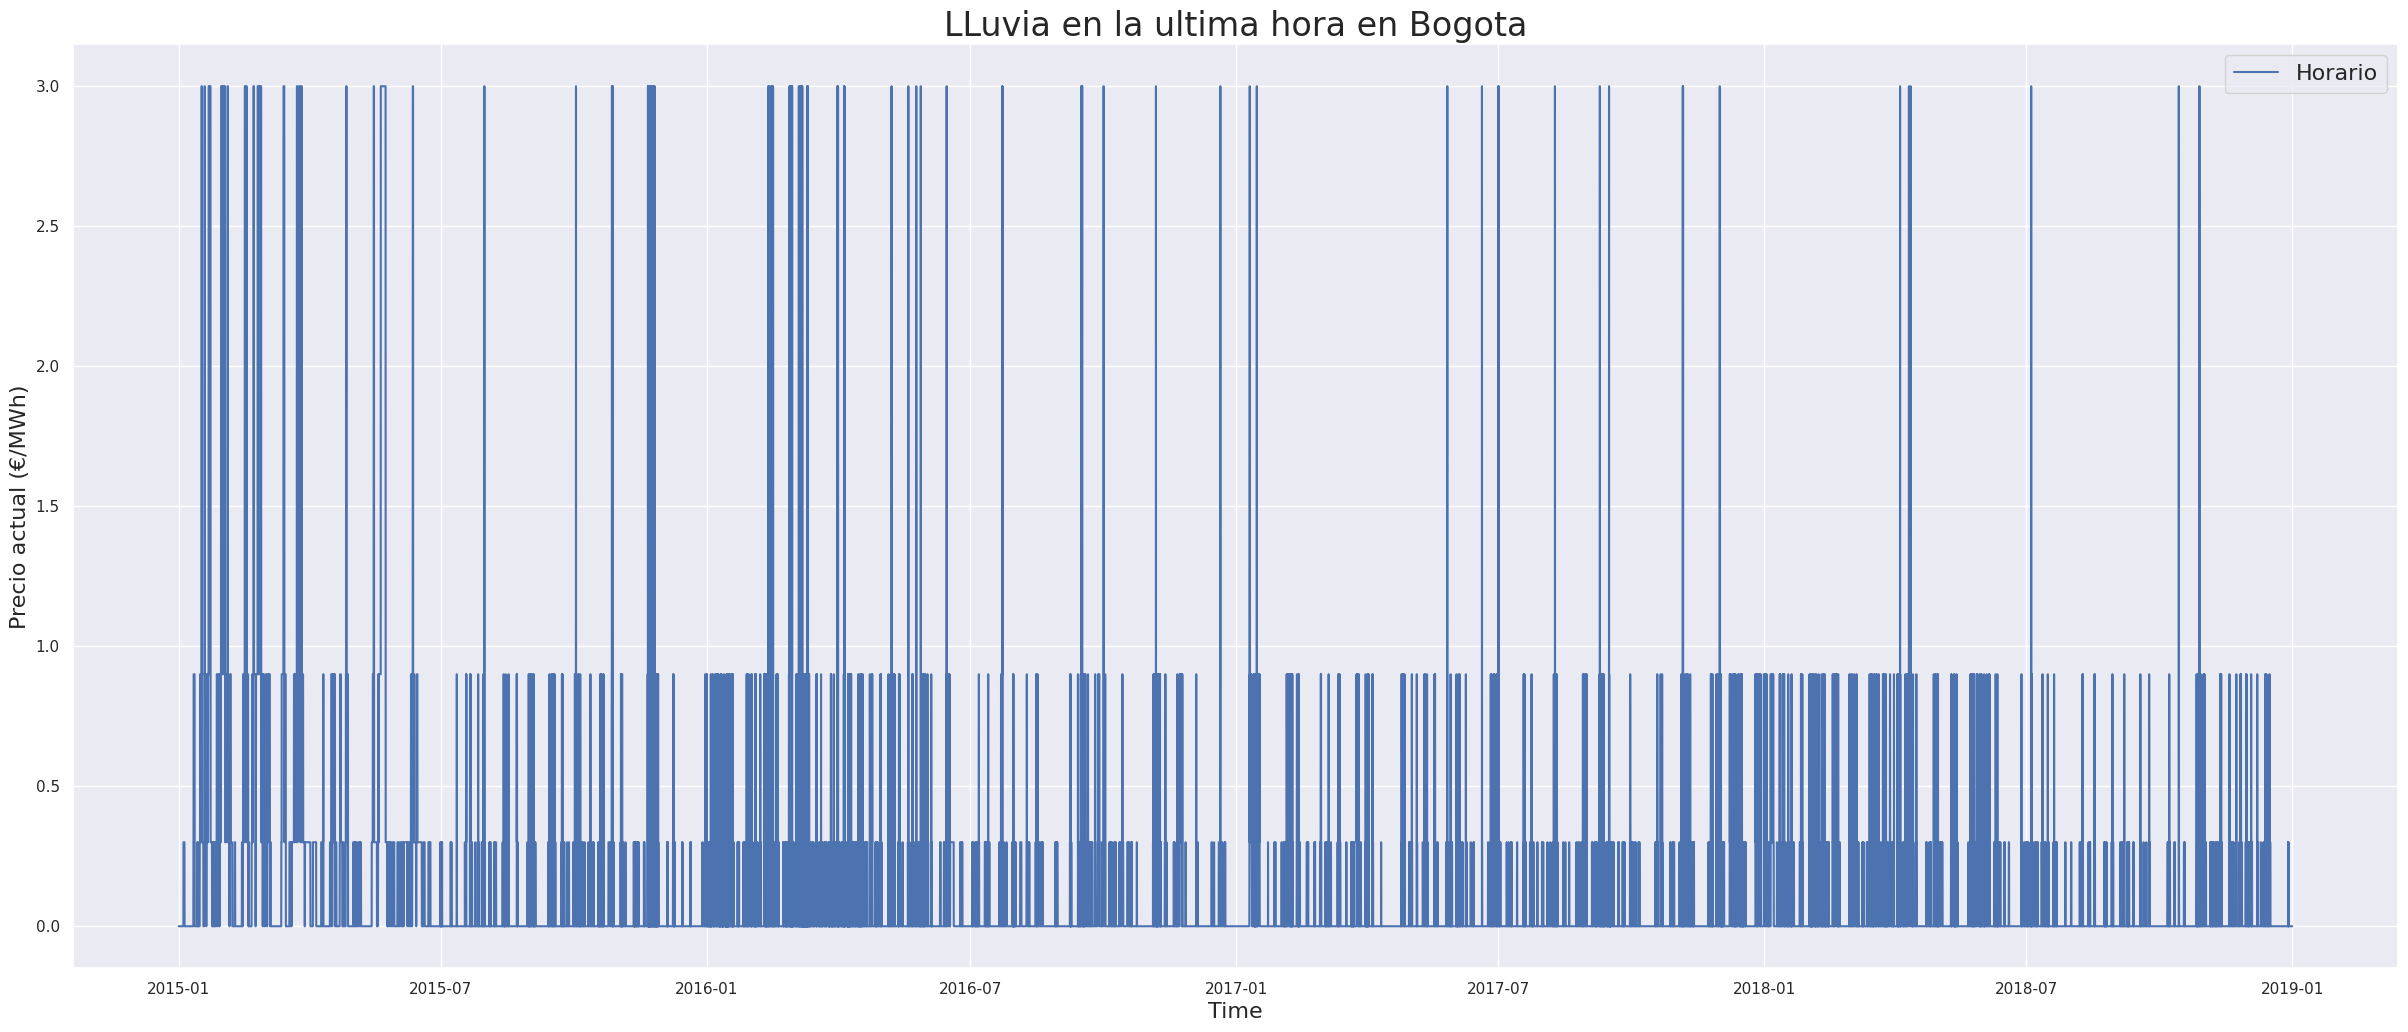

In [ ]:
# Grafiquemos 'rain_1h' para Bogota

ax = plot_series(df_final, 'rain_1h_Bogota',
                 label='Horario', ylabel='Precio actual (€/MWh)',
                 title='LLuvia en la ultima hora en Bogota')
plt.show()

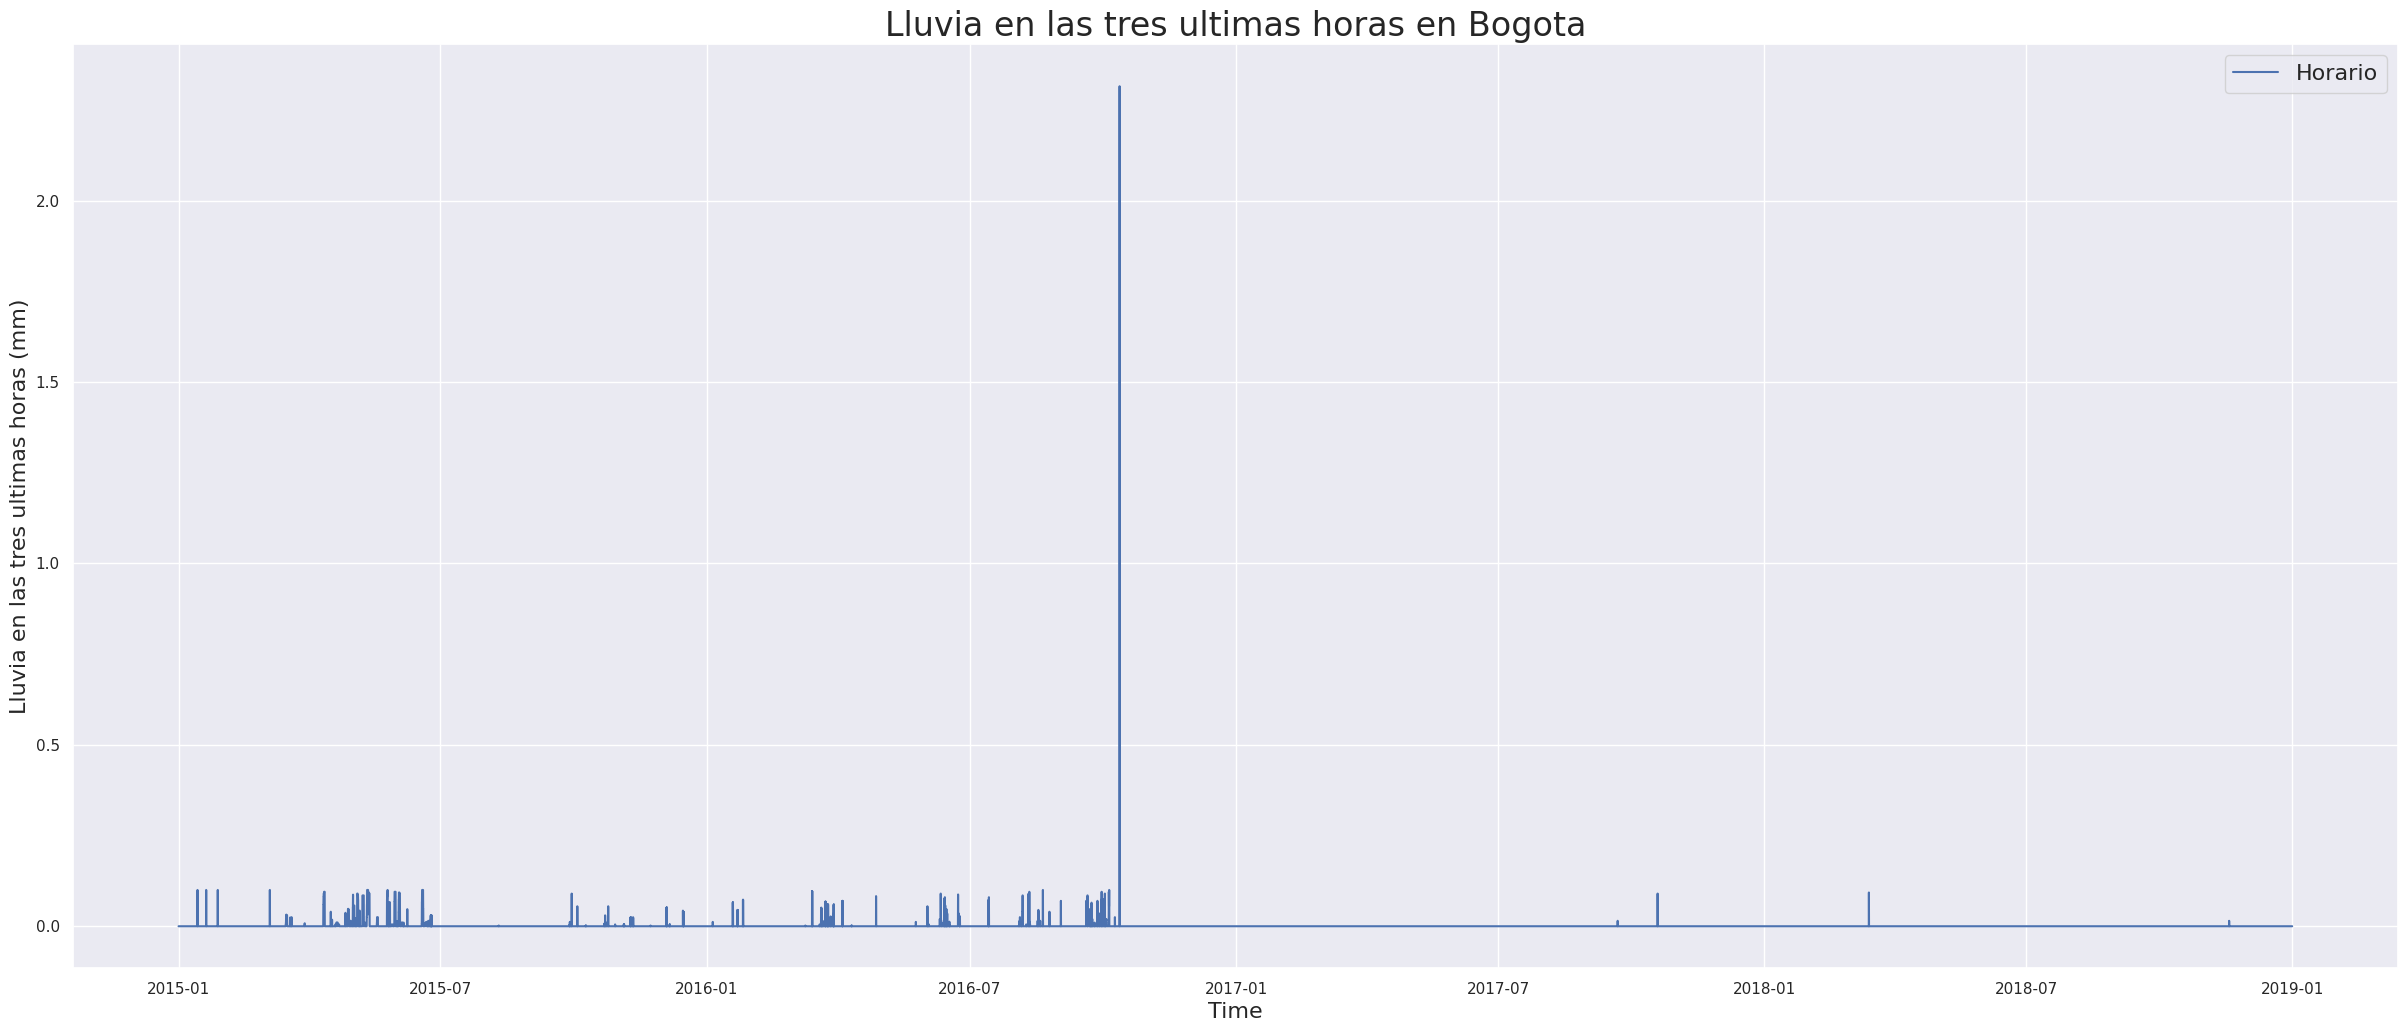

In [ ]:
# Grafiquemos 'rain_3h' para Bogota

ax = plot_series(df_final, 'rain_3h_Bogota',
                 label='Horario', ylabel='Lluvia en las tres ultimas horas (mm)',
                 title='Lluvia en las tres ultimas horas en Bogota')
plt.show()

Podemos ver que la caracteristica **3 horas de lluvia** no es representativa, asi que la vamos a eliminar de los datos.

In [ ]:
cities = ['Medellin', 'Bogota', 'Bucaramanga', 'Cali', 'Cartagena']

for city in cities:
    df_final = df_final.drop(['rain_3h_{}'.format(city)], axis=1)

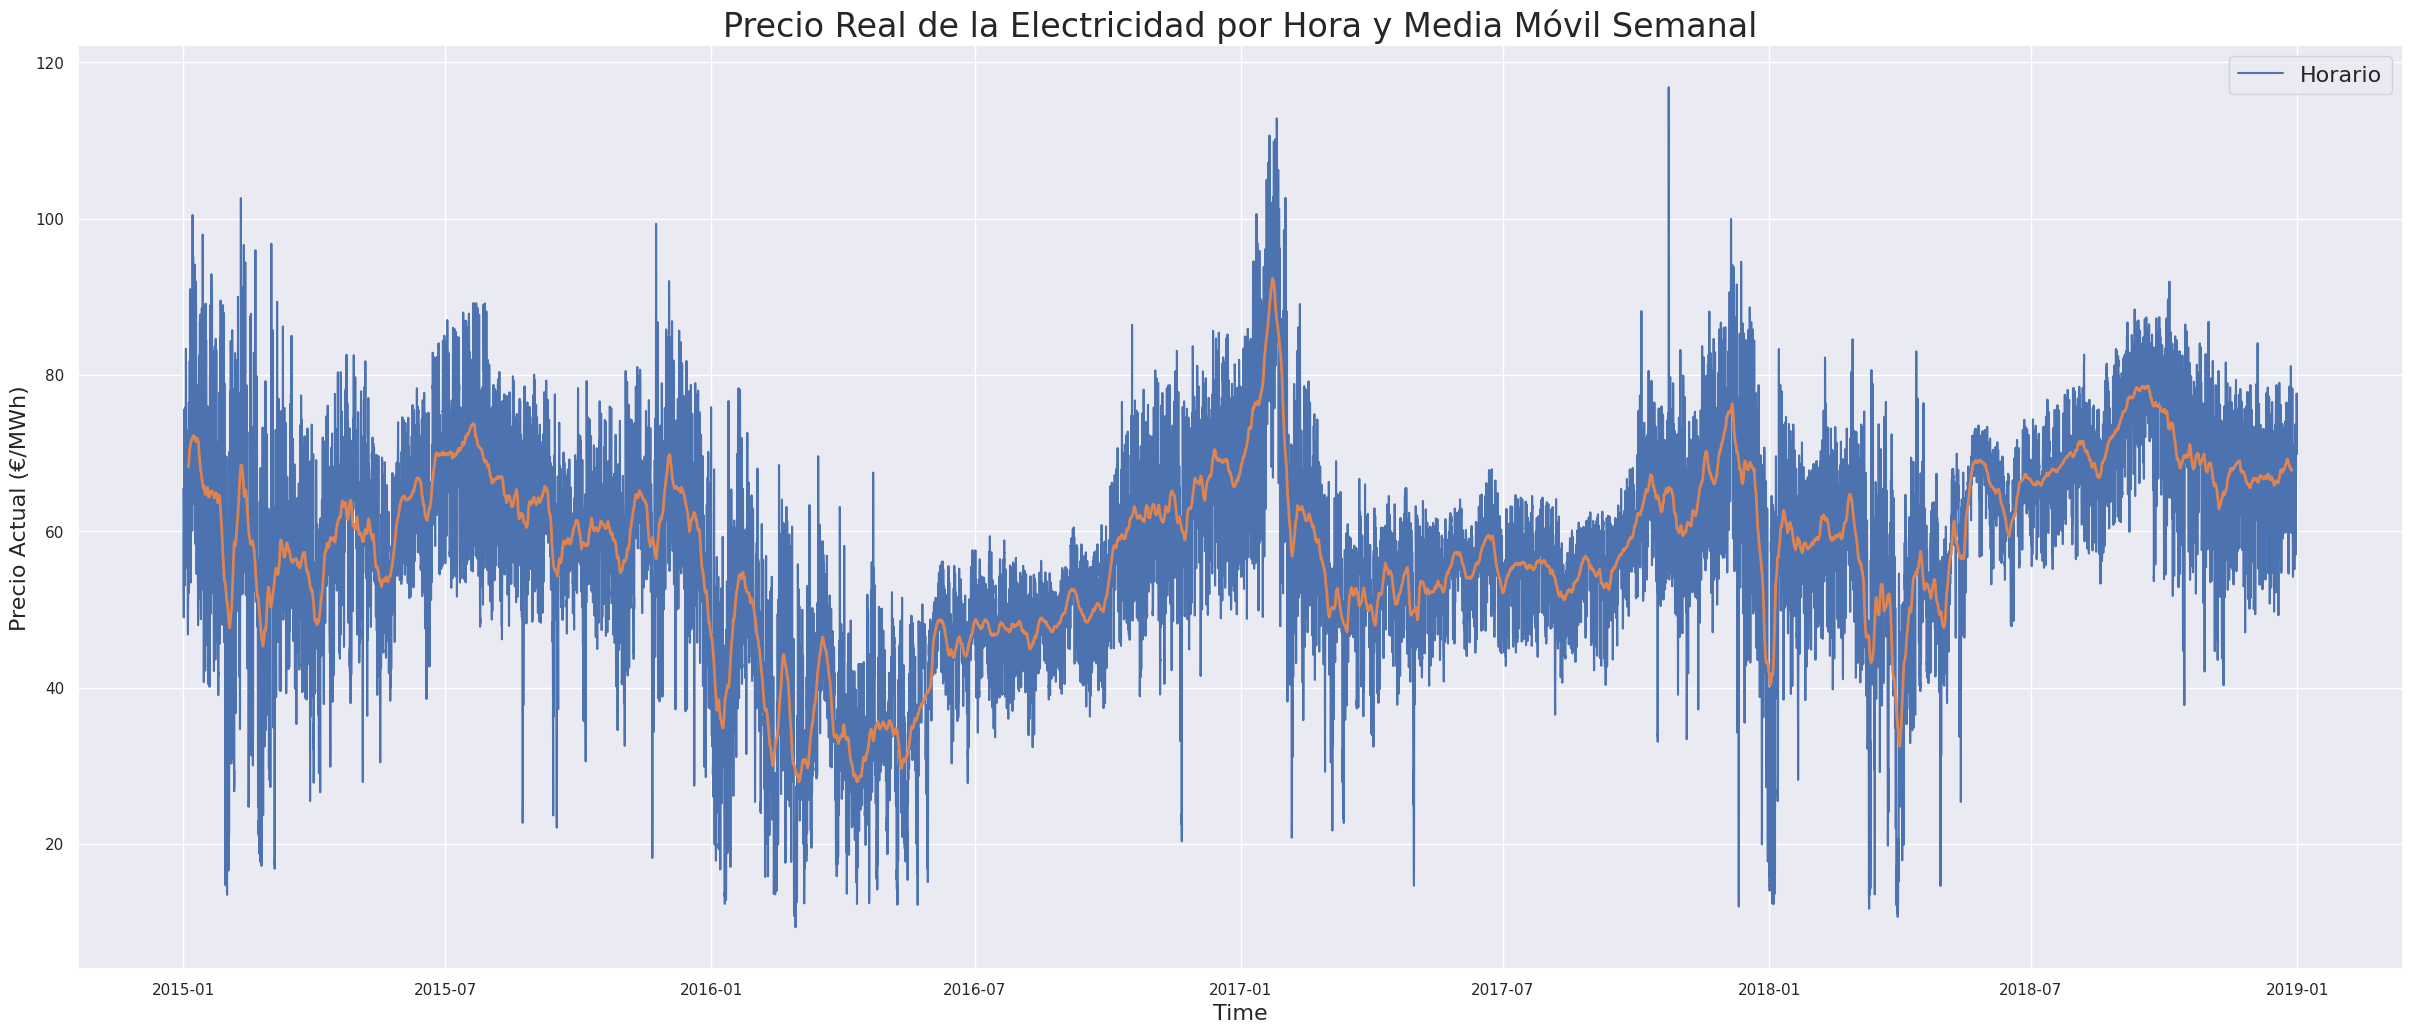

In [ ]:
# Grafica el precio real de la electricidad por hora, junto con la media móvil semanal

rolling = df_final['price actual'].rolling(24*7, center=True).mean()
ax = plot_series(df_final, 'price actual', label='Horario', ylabel='Precio Actual (€/MWh)',
                 title='Precio Real de la Electricidad por Hora y Media Móvil Semanal')
ax.plot(rolling, linestyle='-', linewidth=2, label='Weekly rolling mean')
plt.show()

**rolling(24*7, center=True):** Aplica la función de **rolling (deslizamiento)** para calcular la media móvil. El argumento 24*7 indica el tamaño de la ventana de 168 horas (24 horas * 7 días), lo que significa que se calcula la media de una semana.

**center=True** indica que la ventana estará centrada en el tiempo actual, es decir, toma datos tanto del pasado como del futuro respecto al punto actual para calcular la media.

**.mean():** Calcula la media de los valores dentro de la ventana especificada para cada punto, resultando en la serie rolling que representa la media móvil semanal del precio de la electricidad.

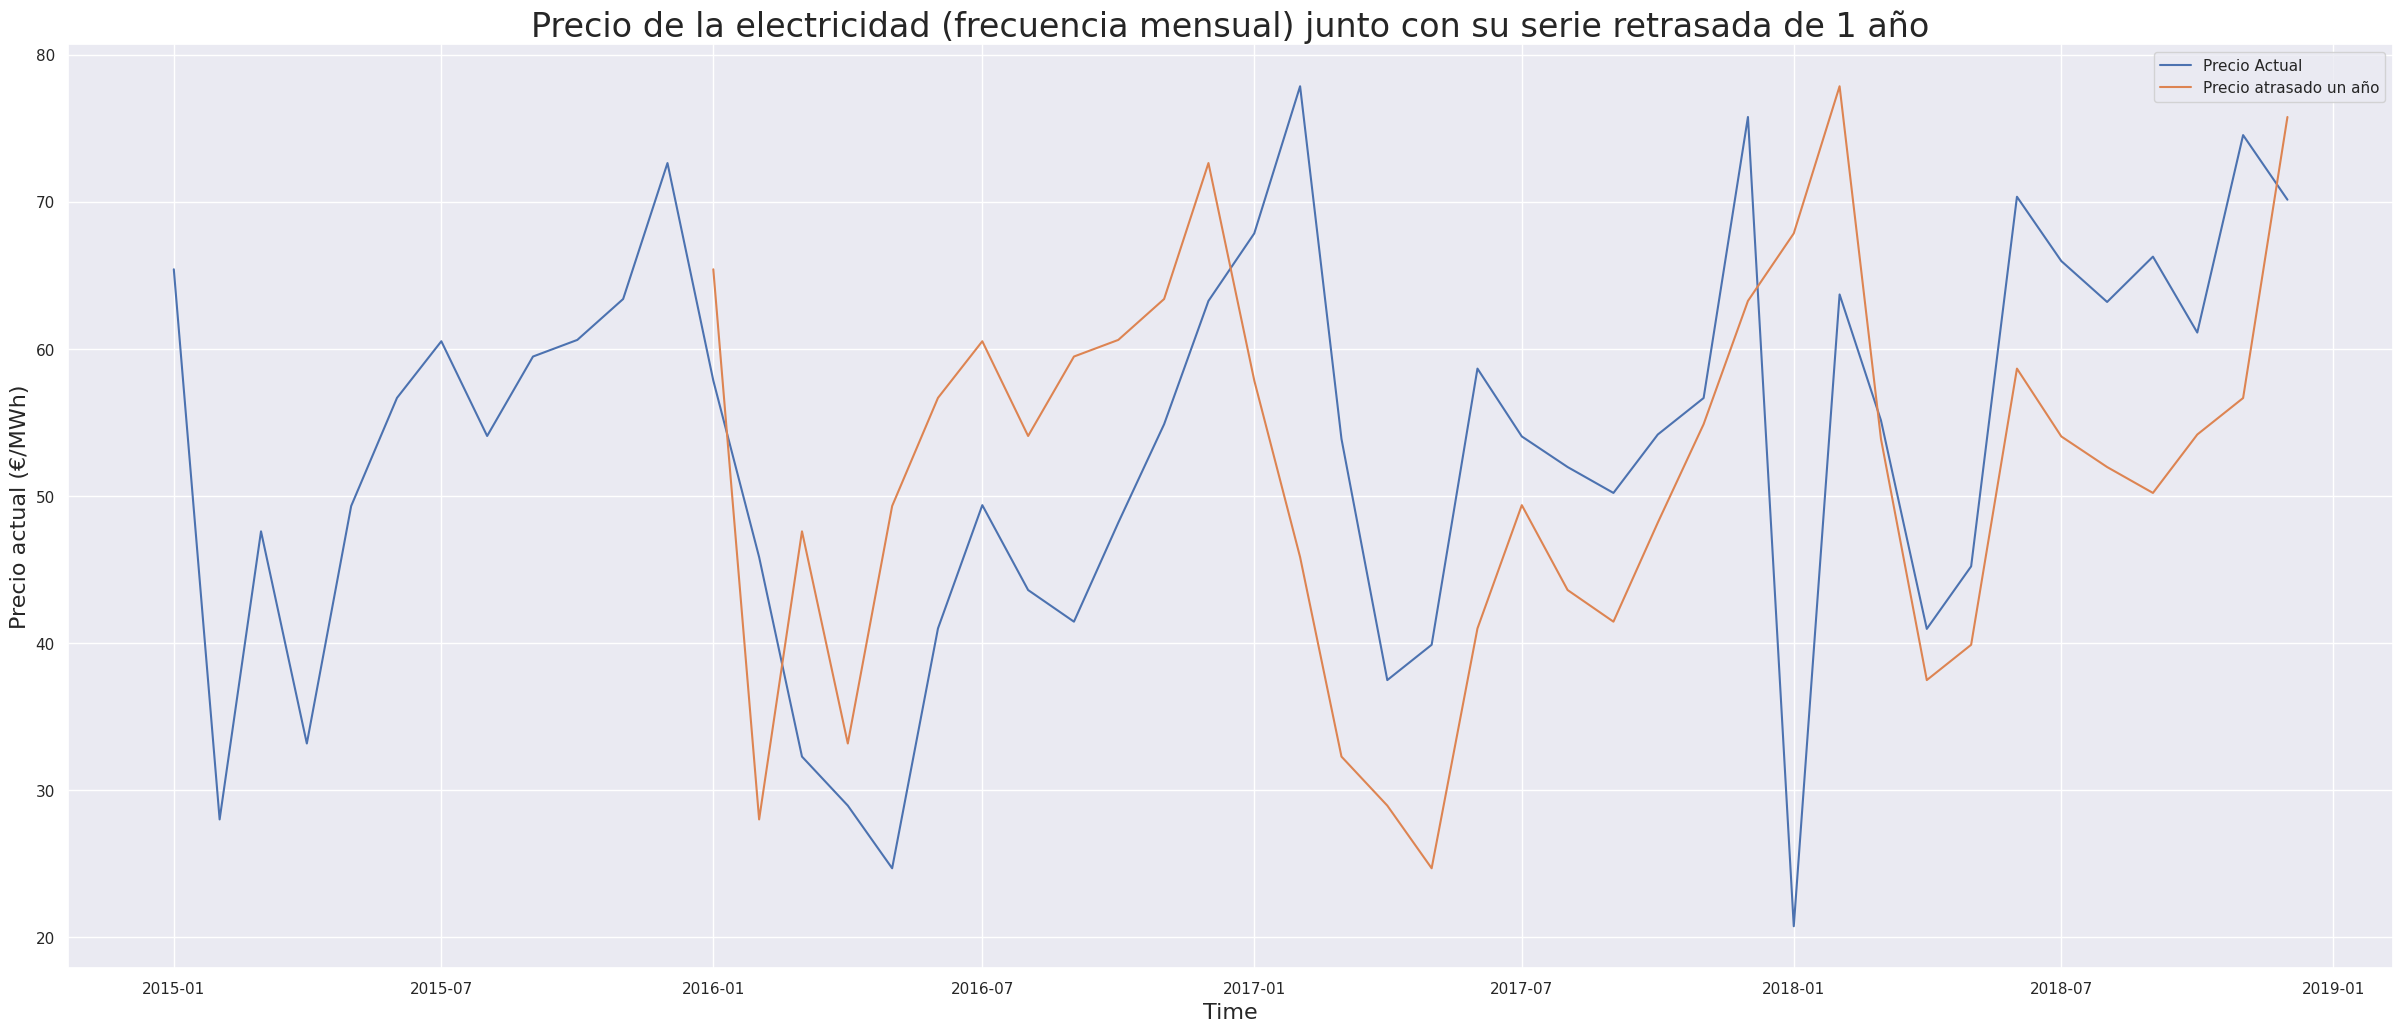

In [ ]:
# Grafiquemos el precio de la electricidad (monthly frequence) junto con su serie retrasada de 1 año

monthly_price = df_final['price actual'].asfreq('M')
ax = plot_series(series=monthly_price, ylabel='Precio actual (€/MWh)',
                 title='Precio de la electricidad (frecuencia mensual) junto con su serie retrasada de 1 año')
shifted = df_final['price actual'].asfreq('M').shift(12)
ax.plot(shifted, label='Hourly')
ax.legend(['Precio Actual', 'Precio atrasado un año'])
plt.show()

La figura anterior muestra la **frecuencia mensual (remuestreada) del precio real de la electricidad, junto con su frecuencia mensual retrasada de 1 año**.

Podemos ver que  hay patrones estacionales a escala mensual, ya que ciertos "picos" en la serie temporal ocurren exactamente en los mismos meses. Esto significa que sería una buena idea crear una nueva característica para los meses.

**1. Identificar Patrones Estacionales**

**2. Mejorar la Comprensión de la Dinámica Temporal**

**3. Desarrollo de Características para Modelos Predictivos**

**4. Evaluación de la Autocorrelación**

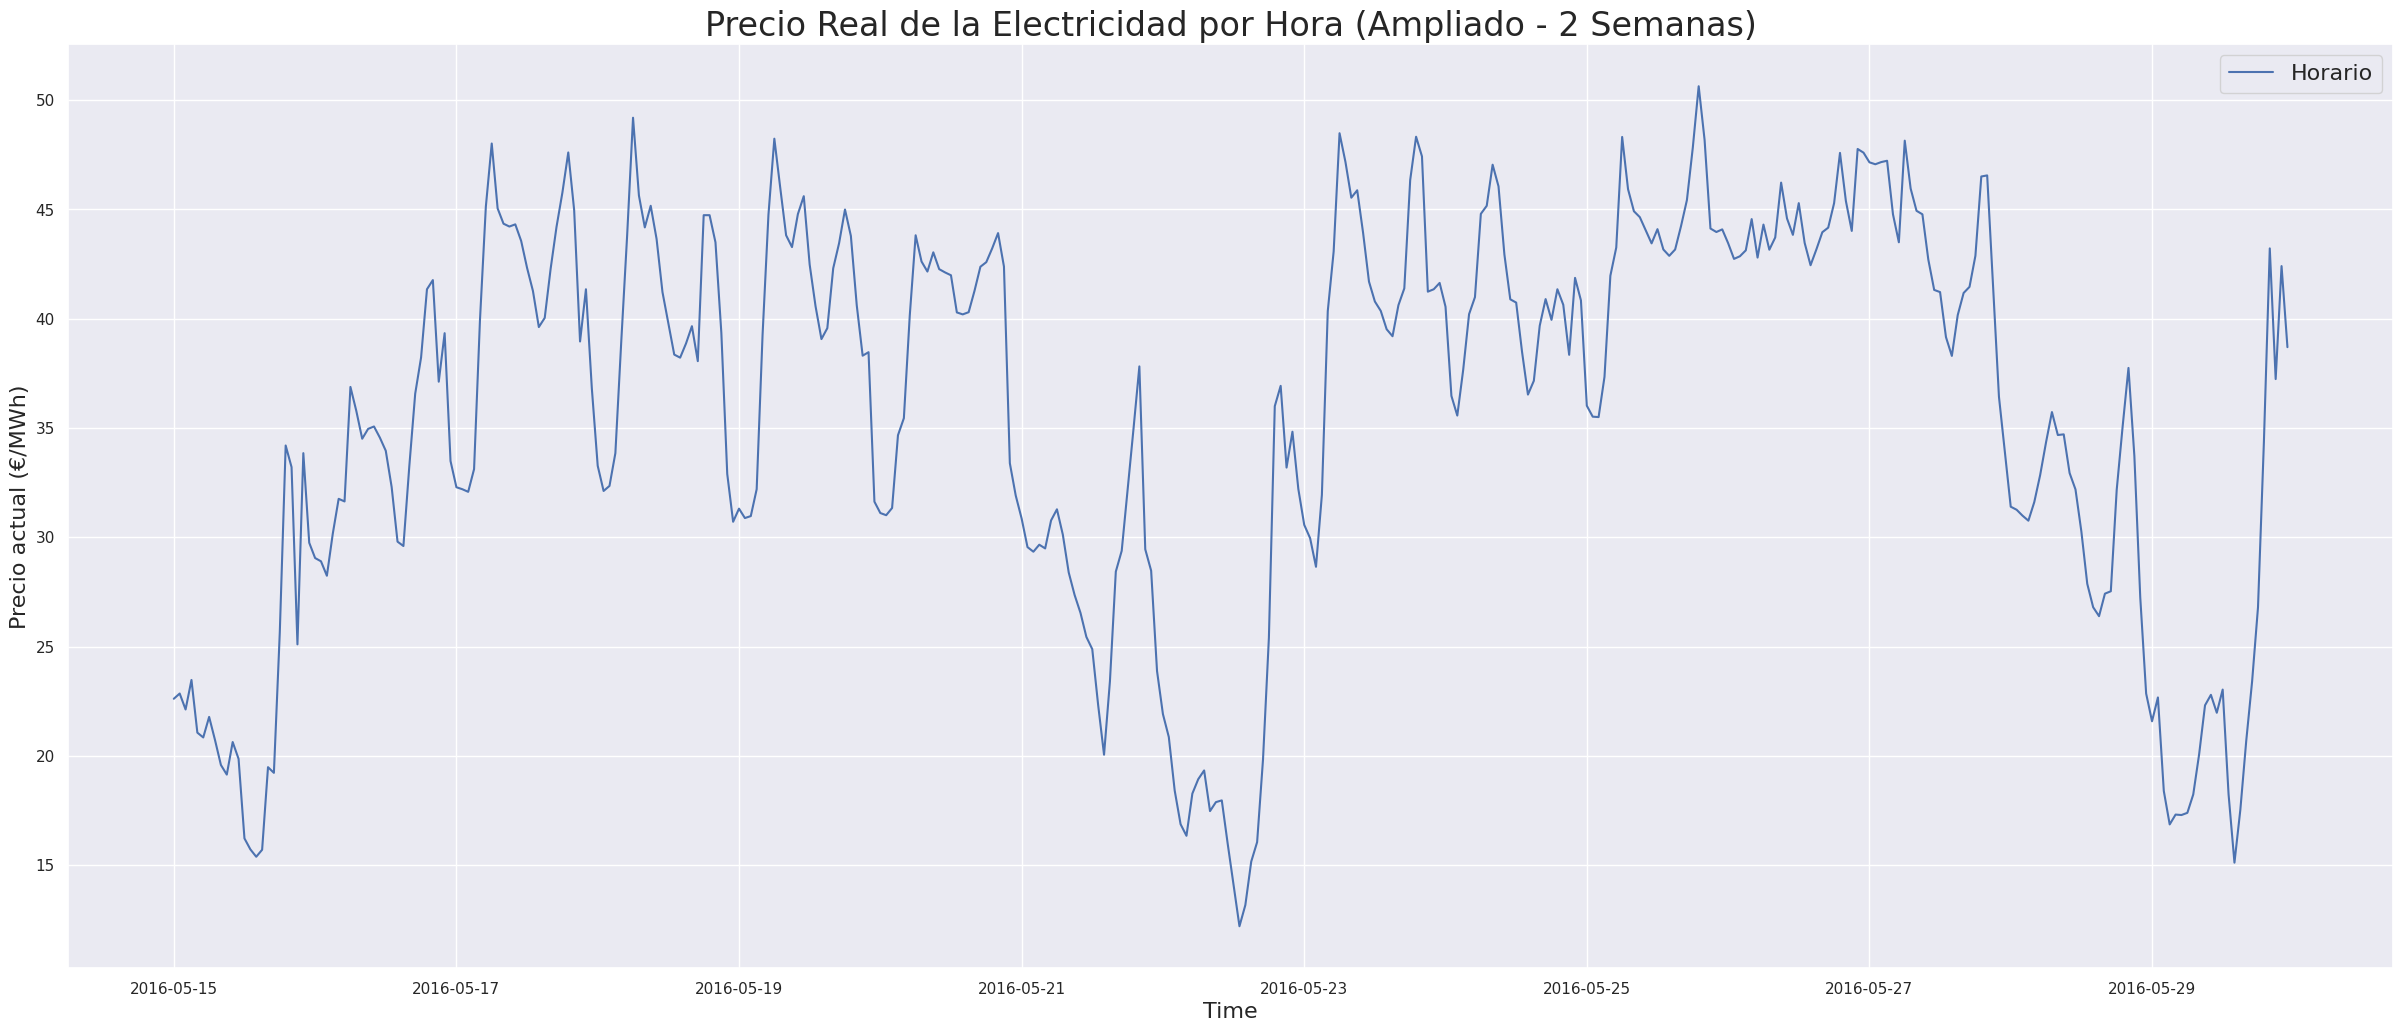

In [ ]:
# Grafica el precio real de la electricidad a una escala diaria/semanal

ax = plot_series(df_final, 'price actual', label='Horario', ylabel='Precio actual (€/MWh)',
                 start=1 + 24 * 500, end=1 + 24 * 515,
                 title='Precio Real de la Electricidad por Hora (Ampliado - 2 Semanas)')
plt.show()

En la figura anterior, hemos graficado el **precio real de la electricidad por hora desde el 15/06/2016 (domingo) a las 00:00 hasta el 29/06/2016 (domingo) a las 23:00**, es decir, dos semanas de datos. Podemos observar que hay muchos patrones y periodicidades, tales como:

**Una periodicidad de semana a semana**, ya que el precio de la electricidad tiende a ser más alto durante los días laborables y más bajo durante los fines de semana y especialmente durante los domingos.

**Una periodicidad intradiaria,** ya que el precio es más alto durante el día y más bajo durante la noche.

**Una periodicidad dentro del horario laboral,** ya que en algunos casos el precio de la electricidad cae por unas horas, lo cual probablemente se debe a la "siesta", el descanso tradicional para el almuerzo entre la 01:30 p.m. y las 04:30 p.m., ya que España no sigue estrictamente el día laboral de 9 a.m. a 5 p.m.

Más adelante, nos aseguraremos de generar características que contengan este tipo de información.

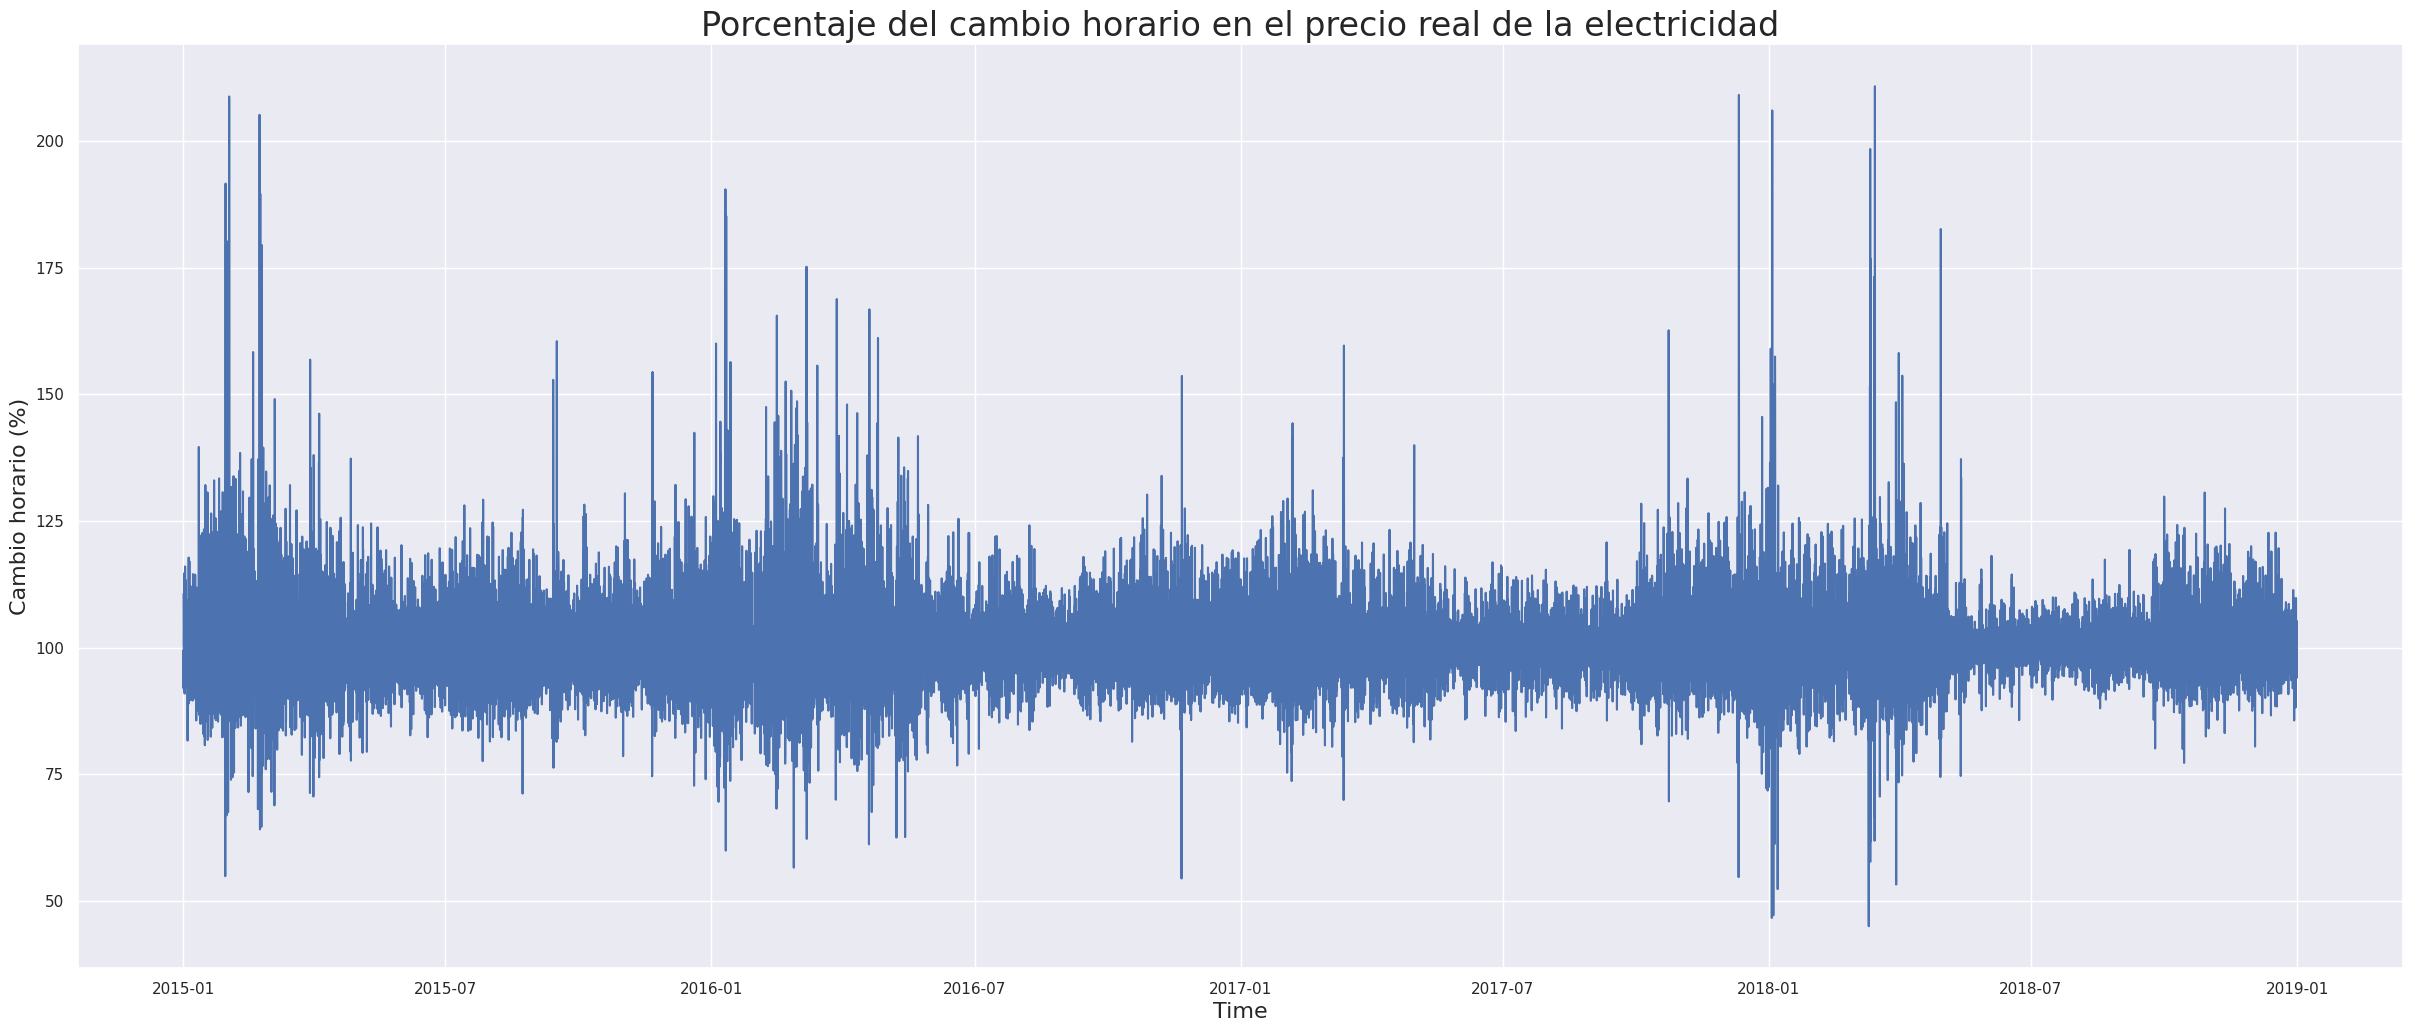

In [ ]:
# Grafica el porcentaje del cambio horario en el precio actual de la electricidad

change = df_energy['price actual'].div(df_energy['price actual'].shift(1)).mul(100)
ax = plot_series(series=change, ylabel='Cambio horario (%)',
                 title='Porcentaje del cambio horario en el precio real de la electricidad')
plt.show()


Podemos ver que el cambio en el precio real de hora en hora, en la mayoría de los casos, está entre -25% (precio actual * 0.75) y +25% (precio actual * 1.25). Sin embargo, también hay muy pocos valores atípicos que muestran que el precio se reduce a la mitad (-50%) o se duplica (+100%).


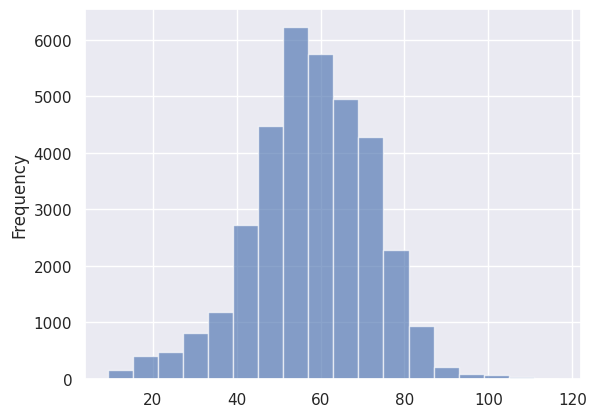

In [ ]:
# Grafiquemos el histograma del precio actual de la electricidad

ax = df_energy['price actual'].plot.hist(bins=18, alpha=0.65)

Vemos que el precio real de la energía sigue aproximadamente una distribución normal y, por lo tanto, podría ser estandarizado. Sin embargo, también tenemos que asegurarnos de que la serie temporal no requiera ningún otro tipo de transformaciones. Más específicamente, verificaremos si la serie temporal del precio de la energía es estacionaria, después de visualizar sus componentes descompuestos en series temporales.

# **2.2. Decomposicion y pruebas estacionarias**

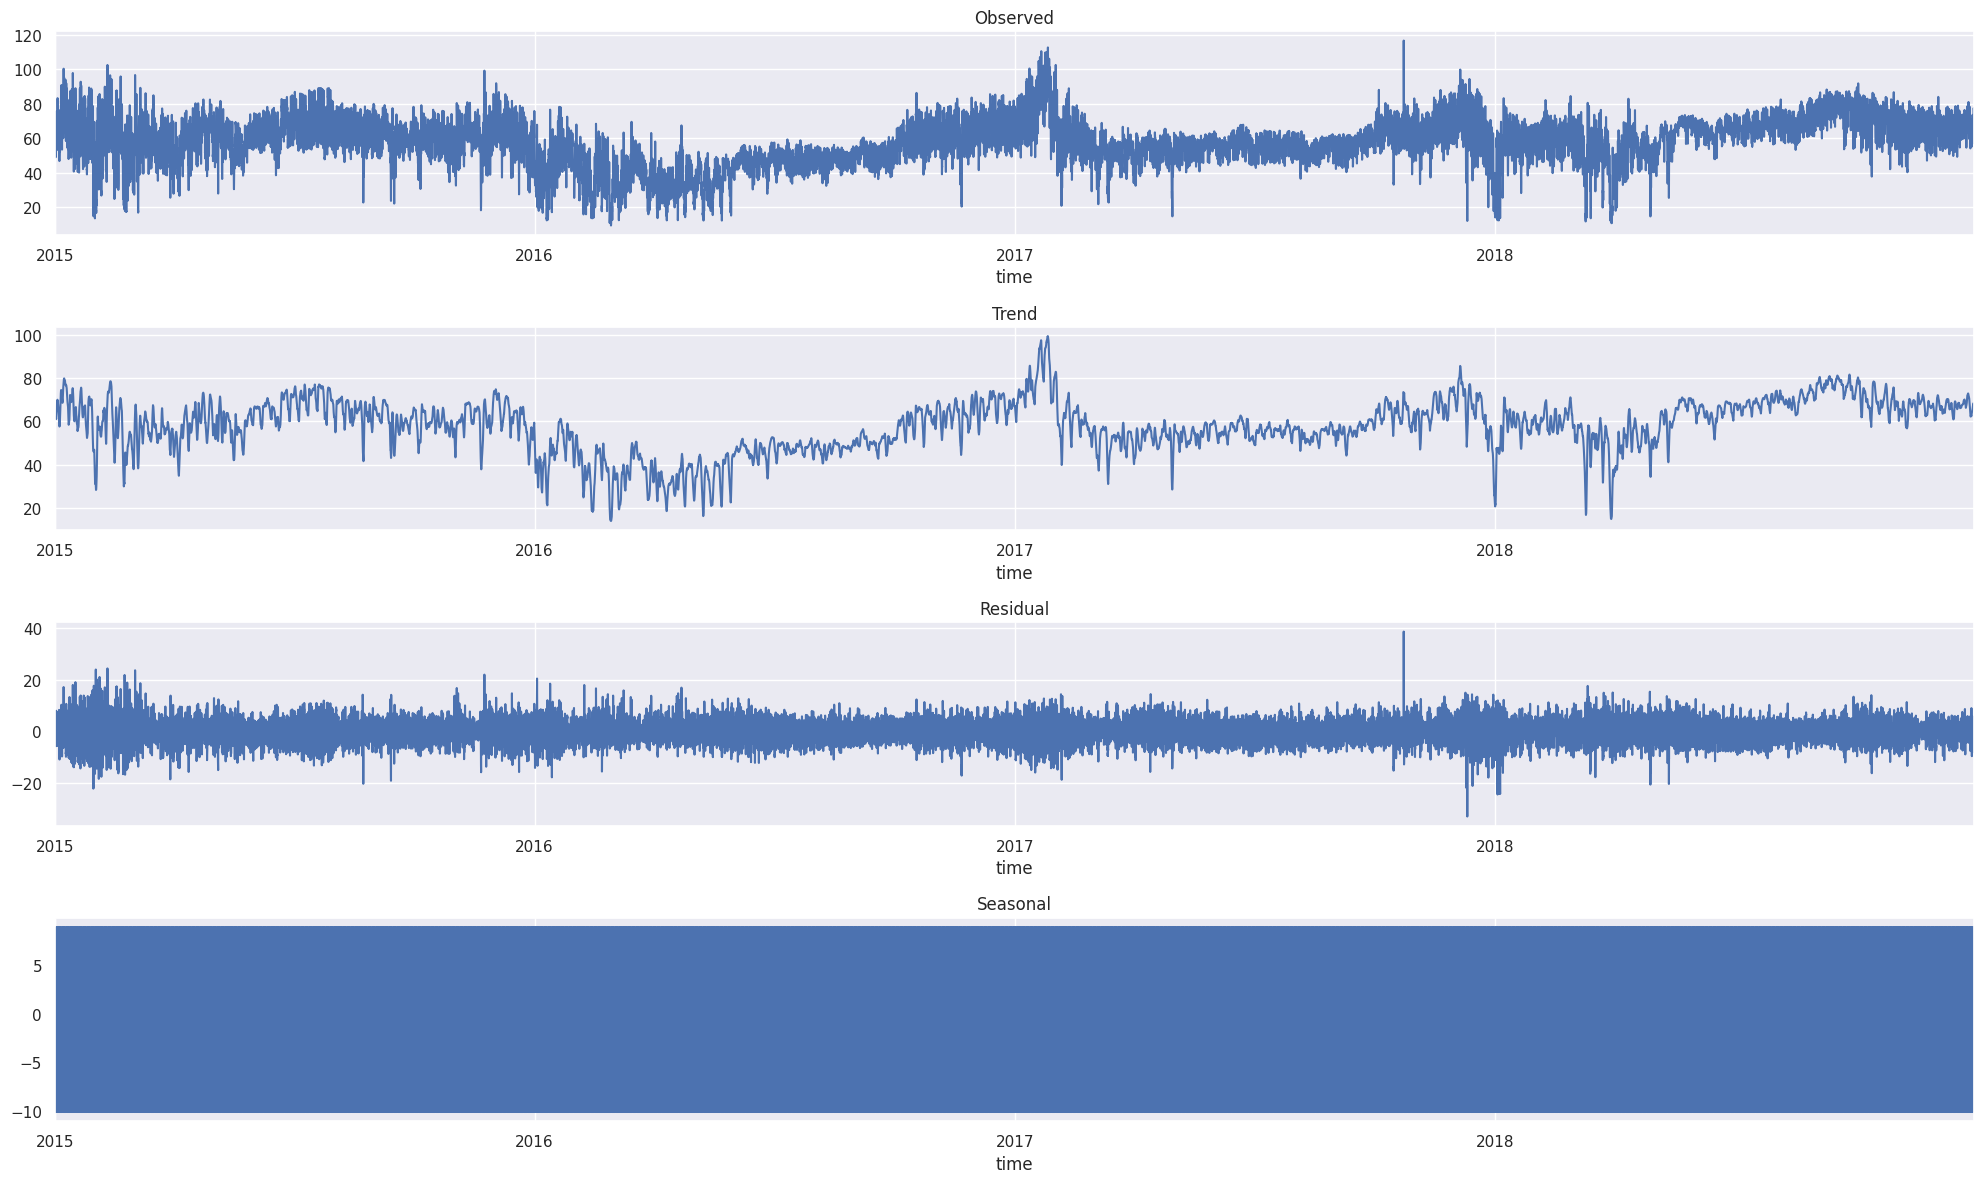

In [ ]:
# Descomponer la serie temporal del precio de la electricidad

res = sm.tsa.seasonal_decompose(df_energy['price actual'], model='additive')

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(20, 12))
res.observed.plot(ax=ax1, title='Observed')
res.trend.plot(ax=ax2, title='Trend')
res.resid.plot(ax=ax3, title='Residual')
res.seasonal.plot(ax=ax4, title='Seasonal')
plt.tight_layout()
plt.show()

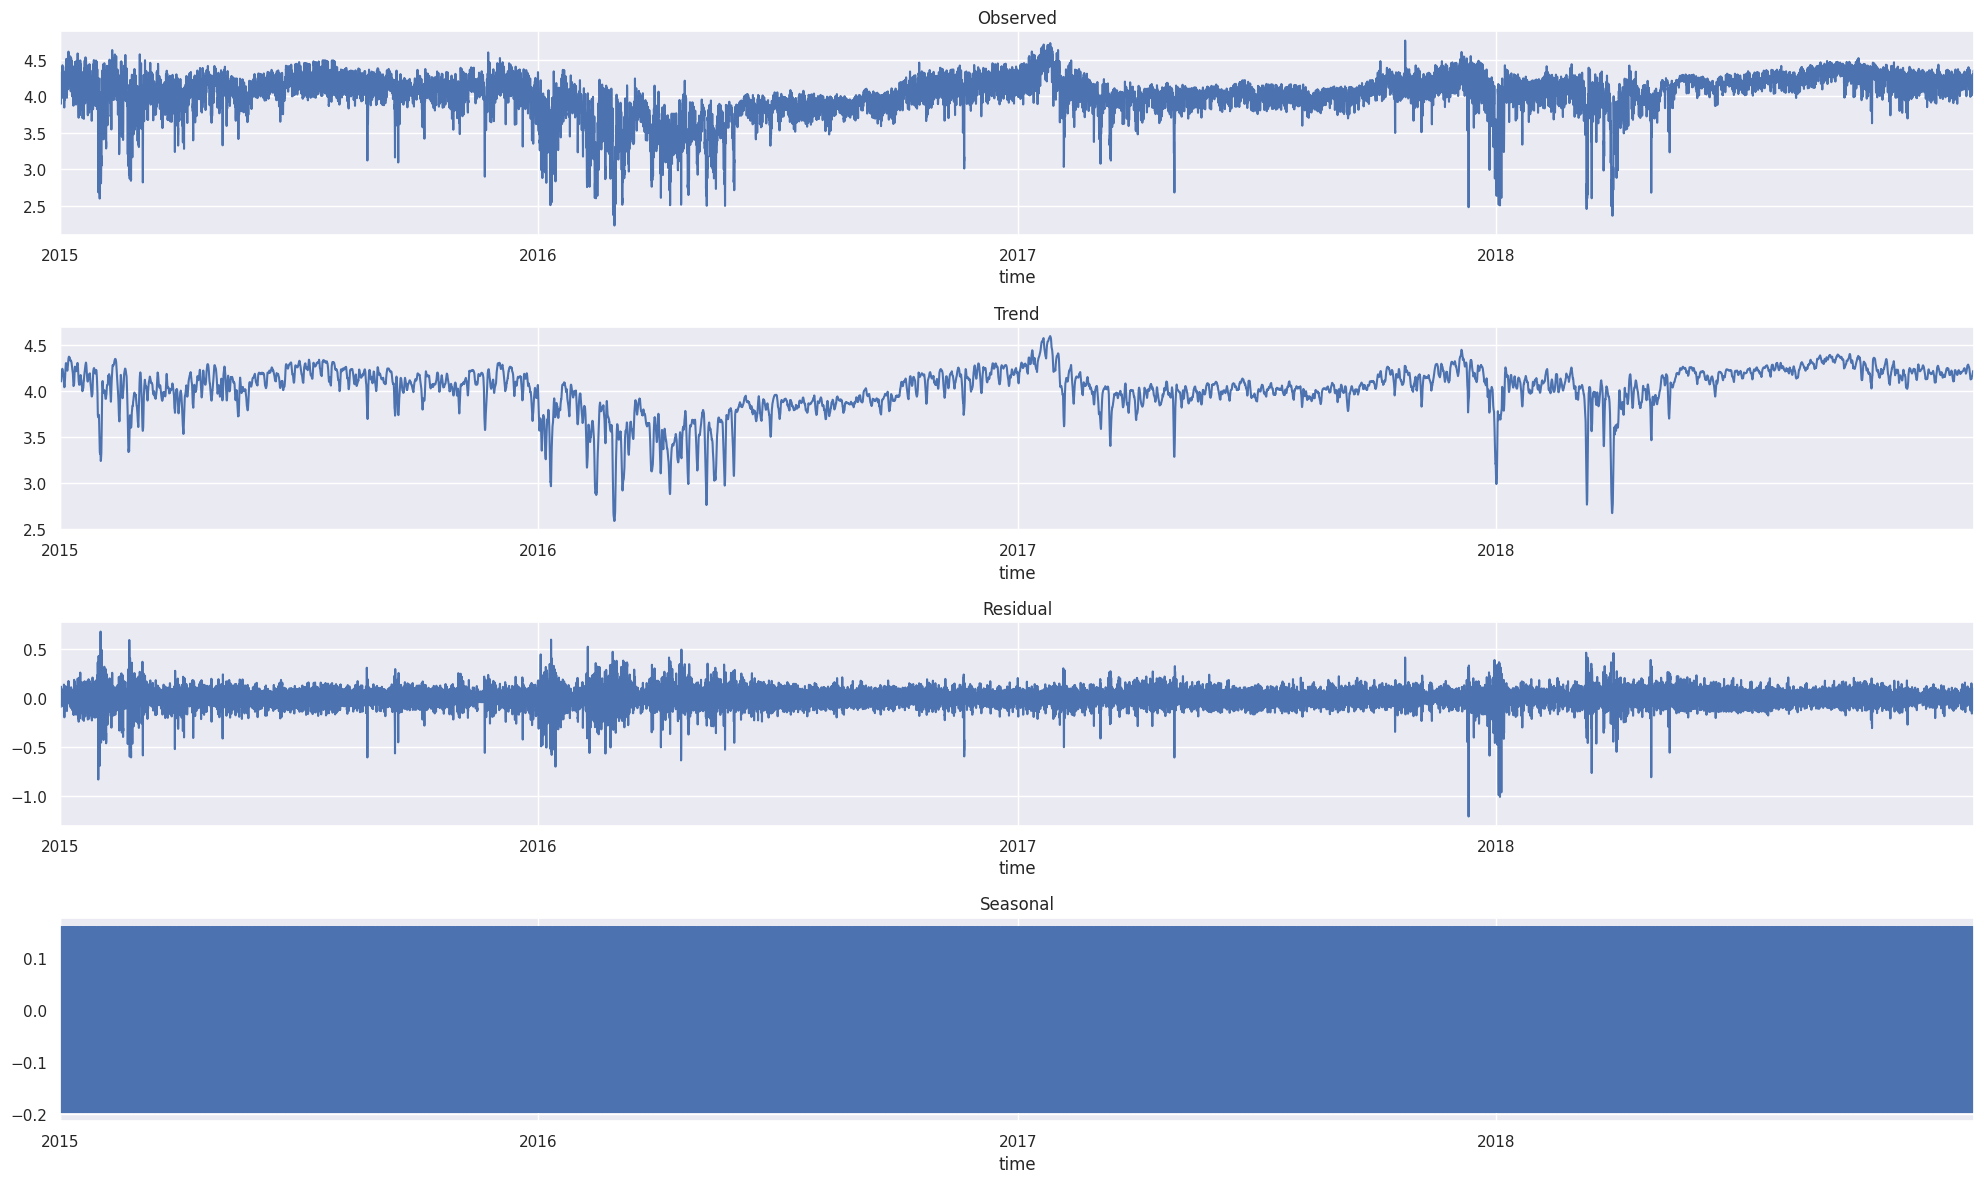

In [ ]:
# Descomponer la serie temporal del registro del precio de la electricidad

res = sm.tsa.seasonal_decompose(np.log(df_energy['price actual']), model='additive')

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(20, 12))
res.observed.plot(ax=ax1, title='Observed')
res.trend.plot(ax=ax2, title='Trend')
res.resid.plot(ax=ax3, title='Residual')
res.seasonal.plot(ax=ax4, title='Seasonal')
plt.tight_layout()
plt.show()

**La prueba de Dickey-Fuller Aumentada (ADF),** un tipo de prueba de raíz unitaria, determina cuán fuertemente una serie temporal está definida por una tendencia. Sus hipótesis son las siguientes:

**Hipótesis Nula 𝐻0:** Hay una raíz unitaria en la serie temporal, es decir, la serie está autocorrelacionada con (r=1), una estructura dependiente del tiempo y, por lo tanto, no es estacionaria.

**Hipótesis Alternativa 𝐻1:** La serie temporal no tiene raíz unitaria y es estacionaria o puede hacerse estacionaria mediante diferenciación.

In [ ]:
y = df_final['price actual']
adf_test = adfuller(y, regression='c')
print('ADF Statistic: {:.6f}\np-value: {:.6f}\n#Lags used: {}'
      .format(adf_test[0], adf_test[1], adf_test[2]))
for key, value in adf_test[4].items():
    print('Critical Value ({}): {:.6f}'.format(key, value))

ADF Statistic: -9.147016
p-value: 0.000000
#Lags used: 50
Critical Value (1%): -3.430537
Critical Value (5%): -2.861623
Critical Value (10%): -2.566814



**La estadística ADF (-9.147)** es **menor que el valor crítico al 1% (-3.431)** y, por lo tanto,**podemos decir que rechazamos la hipótesis nula 𝐻0 con un nivel de significancia del 1%,** lo que **significa** que no hay una raíz-unitaria en la serie temporal y, por lo tanto, que **es estacionaria o podría hacerse estacionaria con diferenciación de primer orden** (diferencia-estacionaria).

**La prueba de Kwiatkowski-Phillips-Schmidt-Shin (KPSS),** sigue la lógica opuesta a la prueba de Dickey-Fuller Aumentada y verifica la estacionariedad. Sus hipótesis son las siguientes:

**Hipótesis Nula 𝐻0:** La serie temporal es de nivel, es decir, es estacionaria alrededor de una constante.

**Hipótesis Alternativa 𝐻1:** Hay una raíz unitaria en la serie temporal y por lo tanto no es estacionaria.

In [ ]:
kpss_test = kpss(y, regression='c', nlags='legacy')
print('KPSS Statistic: {:.6f}\np-value: {:.6f}\n#Lags used: {}'
      .format(kpss_test[0], kpss_test[1], kpss_test[2]))
for key, value in kpss_test[3].items():
    print('Critical Value ({}): {:.6f}'.format(key, value))

KPSS Statistic: 7.957007
p-value: 0.010000
#Lags used: 52
Critical Value (10%): 0.347000
Critical Value (5%): 0.463000
Critical Value (2.5%): 0.574000
Critical Value (1%): 0.739000


La estadística **KPSS (7.957)** es **mayor que** el **valor crítico al 1% (0.739)** y, por lo tanto, **podemos decir** que no podemos rechazar la hipótesis nula 𝐻0 con un nivel de significancia del 1%, lo que significa **que la serie temporal es estacionaria** o estacionaria alrededor de una constante.

# Ambas pruebas concluyeron que la serie temporal del precio de la electricidad es estacionaria.

**También es cierto que las redes neuronales profundas pueden manejar tales propiedades de una manera más indulgente en comparación con los modelos ARIMA.**

# **2.3. Autocorrelacion, Crosscorrelacion y correlacion parcial**

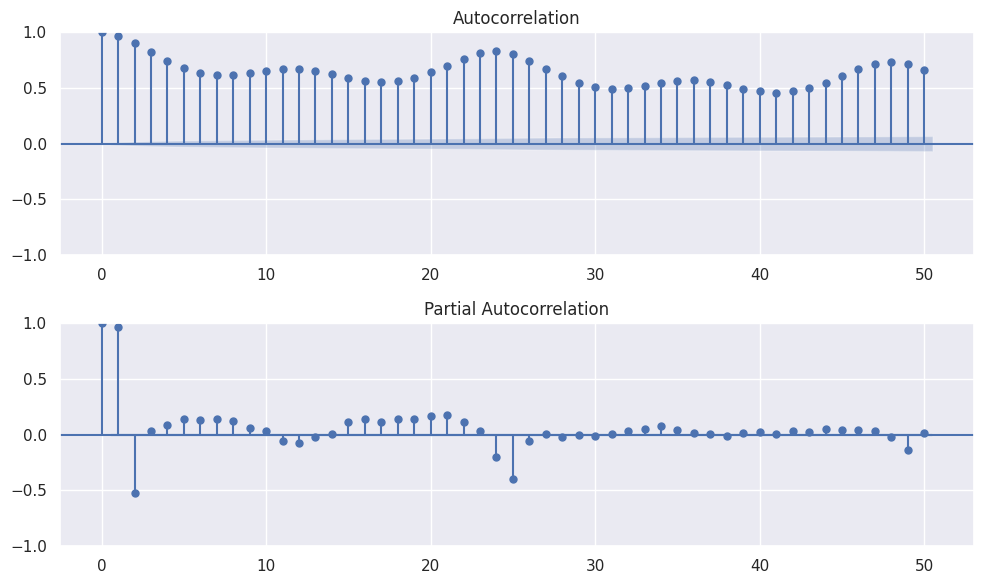

In [ ]:
# Grafiquemos la autocorrelacion y la correlacion parcial de los datos

fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(10, 6))
plot_acf(df_final['price actual'], lags=50, ax=ax1)
plot_pacf(df_final['price actual'], lags=50, ax=ax2)
plt.tight_layout()
plt.show()

**La gráfica de autocorrelación parcial** de la serie temporal del precio de la electricidad **muestra que la relación directa entre una observación en una hora dada (t) es más fuerte con las observaciones en los pasos de tiempo t-1, t-2, t-24 y t-25 y disminuye después.** Por lo tanto, **vamos a utilizar los 25 valores anteriores de cada serie temporal que constituirán una característica para nuestros modelos.**

Sin embargo, definitivamente **sería más beneficioso si solo eligiéramos usar valores pasados específicos** (observaciones en ciertos retrasos temporales) de una característica dada, basados en la correlación cruzada entre el precio de la electricidad y cada una de las características en el conjunto de datos. Por ejemplo, **a continuación, podemos ver la correlación cruzada entre el precio de la electricidad y la carga total.** Vemos que hay muchos retrasos temporales con una correlación que está cerca de cero y podrían ser omitidos.

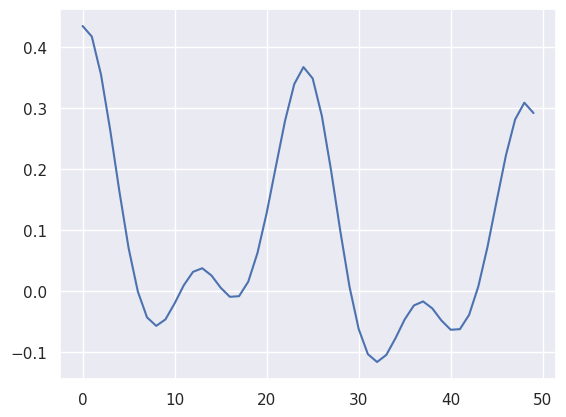

In [ ]:
# Correlacion cruzada o crosscorrelacion
cross_corr = ccf(df_final['total load actual'], df_final['price actual'])
plt.plot(cross_corr[0:50])
plt.show()

In [ ]:
# Encontremos las correlacoines entre el precio de la energia y el resto de features

correlations = df_final.corr(method='pearson')
print(correlations['price actual'].sort_values(ascending=False).to_string())

price actual                                   1.000000
price day ahead                                0.732155
generation fossil hard coal                    0.465637
generation fossil gas                          0.461452
total load actual                              0.435253
generation fossil brown coal/lignite           0.363993
generation fossil oil                          0.285050
generation other renewable                     0.255551
pressure_Bogota                                0.194063
generation waste                               0.168710
pressure_Medellin                              0.167847
generation biomass                             0.142671
temp_min_Cartagena                             0.133141
pressure_Cartagena                             0.109812
temp_min_Medellin                              0.103726
generation other                               0.099914
generation solar                               0.098529
temp_max_Bucaramanga                           0

A partir de lo anterior, ya podemos ver algunas correlaciones muy interesantes entre el precio de la energía que queremos predecir y el resto de las características.

Por ejemplo, **la carga total de energía y la cantidad de energía generada a partir de fuentes relacionadas con combustibles fósiles, está positivamente correlacionada con el precio de la electricidad.** En contraste, **la velocidad del viento en casi todas las ciudades y la cantidad de energía de almacenamiento consumida a través del bombeo hidroeléctrico está negativamente correlacionada con el precio de la energía.**

Procederemos a eliminar 'snow_3h_Medellin' y 'snow_3h_Cali', que dan NaNs en sus correlaciones con el precio real de la electricidad.

In [ ]:
df_final = df_final.drop(['snow_3h_Medellin', 'snow_3h_Cali'], axis=1)

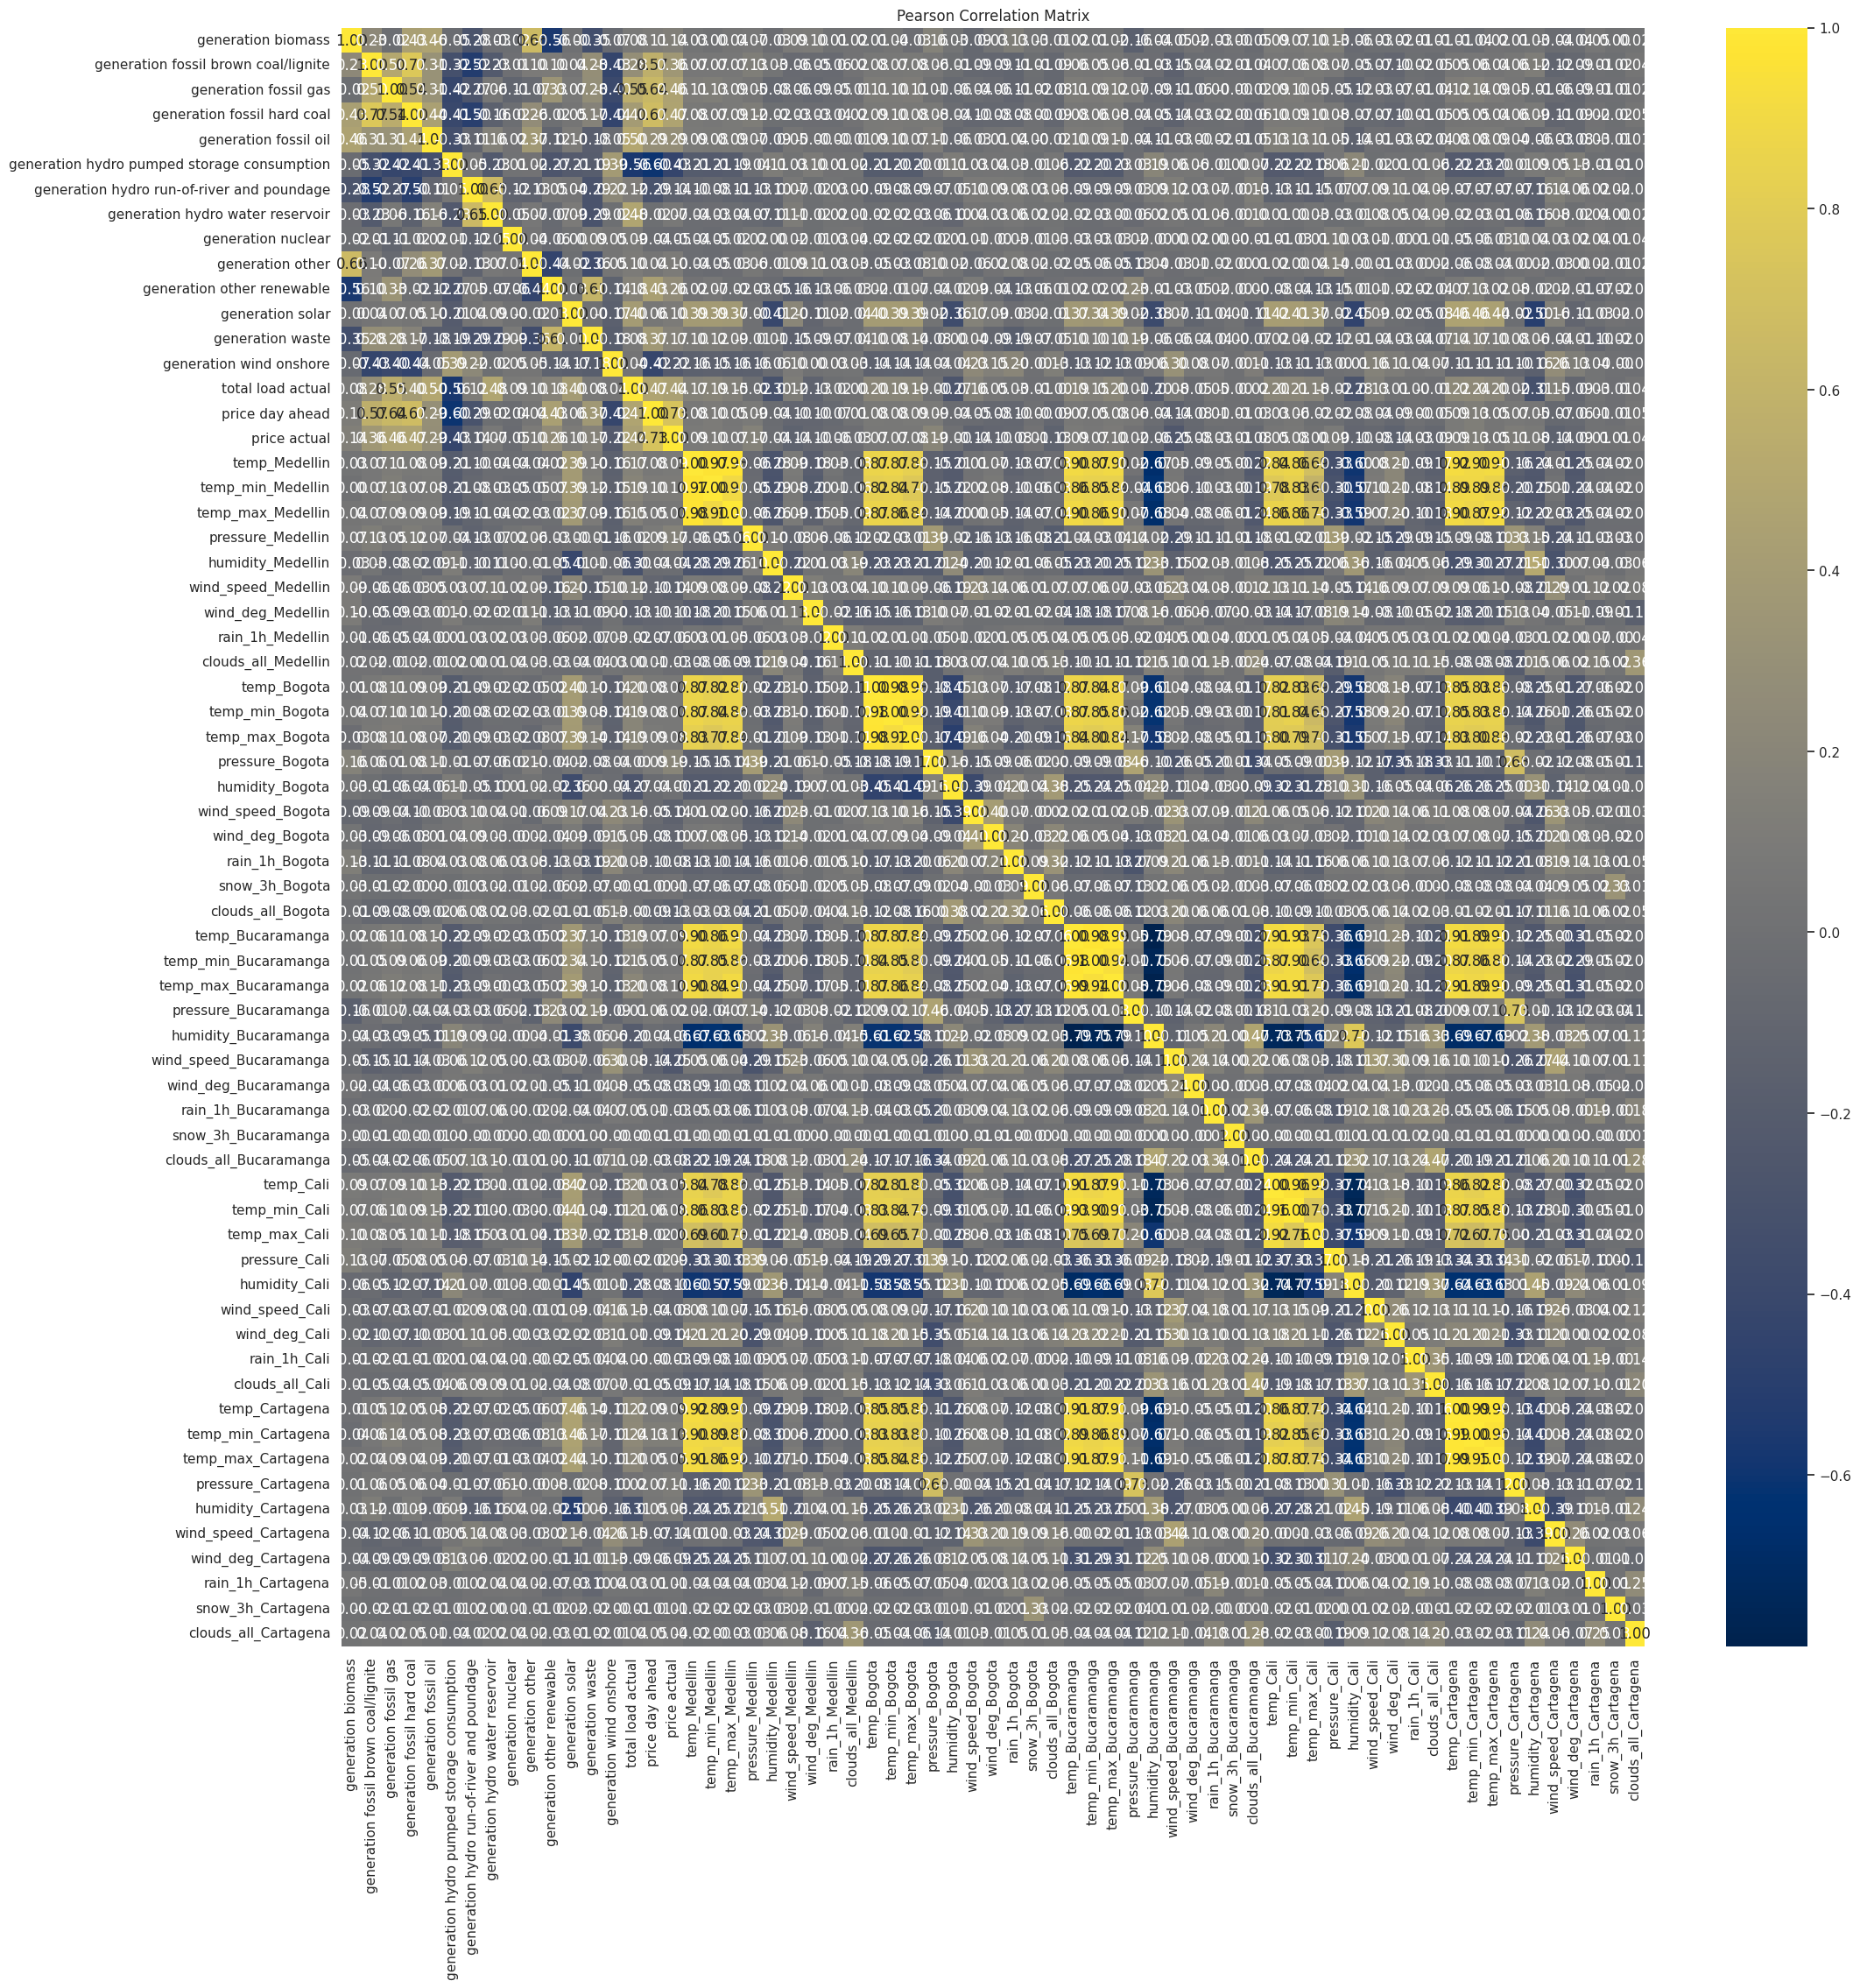

In [ ]:
# Grafiquemos la correlation matrix

correlations = df_final.corr(method='pearson')
fig = plt.figure(figsize=(24, 24))
sns.heatmap(correlations, annot=True, fmt='.2f', cmap='cividis')  # pueden usar la paleta que mas les guste
plt.title('Pearson Correlation Matrix')
plt.show()

**Nombres de algunas paletas de colores**

**viridis:** Una paleta de colores perceptualmente uniforme en tonos verdes-azulados, buena para representar datos ordenados.

**plasma: **Similar a "inferno", pero con una gama de colores que va desde el amarillo brillante hasta el morado oscuro.

**magma:** Una paleta que va desde el negro a través de tonos de rojo y naranja hasta amarillo brillante.

**cividis:** Otra paleta perceptualmente uniforme, optimizada para ser claramente visible a personas con daltonismo.

**coolwarm:** Una paleta divergente que va del azul frío al rojo cálido, útil para datos con un punto medio claro.

**Spectral: **Paleta divergente con una amplia gama de colores, desde el rojo hasta el azul, pasando por tonos de naranja, amarillo y verde.

**RdYlBu:** Abreviatura de Rojo-Amarillo-Azul, otra paleta divergente popular para destacar diferencias en los datos.

**RdYlGn: **Abreviatura de Rojo-Amarillo-Verde, similar a RdYlBu pero utiliza verde en lugar de azul para el extremo inferior.

**Blues:** Una paleta secuencial que va de colores azules claros a oscuros, ideal para resaltar la intensidad en los datos.

**Greens: **Similar a "Blues", pero en tonos de verde, desde los más claros hasta los más oscuros.

In [ ]:
# usemos nuestras librerias de python para ver las mayores correlaciones
highly_correlated = abs(correlations[correlations > 0.75])
print(highly_correlated[highly_correlated < 1.0].stack().to_string())

generation fossil brown coal/lignite  generation fossil hard coal             0.768831
generation fossil hard coal           generation fossil brown coal/lignite    0.768831
temp_Medellin                         temp_min_Medellin                       0.970264
                                      temp_max_Medellin                       0.976904
                                      temp_Bogota                             0.866727
                                      temp_min_Bogota                         0.867970
                                      temp_max_Bogota                         0.828347
                                      temp_Bucaramanga                        0.903996
                                      temp_min_Bucaramanga                    0.874548
                                      temp_max_Bucaramanga                    0.899010
                                      temp_Cali                               0.841910
                                      temp_

# **3. FEATURE ENGINEERING**

# **3.1. Generar caracteristicas**


Las primeras características que generaremos para una hora dada serán simplemente esa hora en particular, el día y el mes en los que ocurre.

In [ ]:
# Generar 'hora', 'dia_laboral' y 'mes' features

for i in range(len(df_final)):
    position = df_final.index[i]
    hora = position.hour
    dia_laboral = position.weekday()
    mes = position.month
    df_final.loc[position, 'hora'] = hora
    df_final.loc[position, 'dia_laboral'] = dia_laboral
    df_final.loc[position, 'mes'] = mes

Una característica muy útil que generaremos tiene que ver con el horario laboral, es decir, si los negocios están abiertos o no en una hora dada. En Colombia, el día laboral de 9 a.m. a 5 p.m. no es seguido generalmente por todos los tipos de negocios, debido a un descanso para almorzar (conocido como "almuerzo") entre medio. Las horas de negocio más usuales son de lunes a sábado, de 9:30 a.m. a 1:30 p.m. y luego nuevamente de 4:30 p.m. a 8 p.m.

Por lo tanto, el valor de la **'hora de negocio'** será igual a **'2'** si la hora dada está dentro del **horario comercial**,

igual a **'1'** si la hora dada está dentro de la **"almuerzo"** intermedia e **igual a '0' para todas las demás horas dadas.**

In [ ]:
# Generar 'Hora de negocio' feature

for i in range(len(df_final)):
    position = df_final.index[i]
    hora = position.hour
    if ((hora > 8 and hora < 14) or (hora > 16 and hora < 21)):
        df_final.loc[position, 'Hora de negocio'] = 2
    elif (hora >= 14 and hora <= 16):
        df_final.loc[position, 'Hora de negocio'] = 1
    else:
        df_final.loc[position, 'Hora de negocio'] = 0


Sin embargo, hemos generado la característica **'hora de negocio'** de tal manera que también incluye los fines de semana, en los cuales hay menos -o diferentes tipos de- negocios abiertos. Por lo tanto, es útil generar también otra característica, **'fin de semana'**, que distinguirá entre días laborables y fines de semana, así como hacer una distinción entre sábados y domingos.

En particular, para una hora dada específica, **el valor de 'fin de semana' será igual a '0'**, si la hora está en un día laborable, **igual a '1' si la hora está en un sábado e igual a '2' si la hora está en un domingo.**

In [ ]:
# Generar 'weekend' feature

for i in range(len(df_final)):
    position = df_final.index[i]
    dia_laboral = position.weekday()
    if (dia_laboral == 6):
        df_final.loc[position, 'dia_laboral'] = 2
    elif (dia_laboral == 5):
        df_final.loc[position, 'dia_laboral'] = 1
    else:
        df_final.loc[position, 'dia_laboral'] = 0


Para reducir la dimensionalidad y potencialmente adquirir un nuevo tipo de información, para cada hora dada, restaremos la temperatura mínima **('temp_min')** de la temperatura máxima **('temp_max') **para cada ciudad y nombraremos esa característica **'temp_range_{nombre de la ciudad}'**

In [ ]:
# Generar 'temp_range' para cada ciudad

cities = ['Medellin', 'Bogota', 'Bucaramanga', 'Cali', 'Cartagena']

for i in range(len(df_final)):
    position = df_final.index[i]
    for city in cities:
        temp_max = df_final.loc[position, 'temp_max_{}'.format(city)]
        temp_min = df_final.loc[position, 'temp_min_{}'.format(city)]
        df_final.loc[position, 'temp_range_{}'.format(city)] = abs(temp_max - temp_min)

Después de ver que hay una alta correlación entre las temperaturas de las diferentes ciudades, también intentaremos crear características de temperatura ponderada teniendo en cuenta la población de cada ciudad.

*   Bogota: 10,155,116
*   Medellin: 3,179,243
*   Cartagena: 1,645,342
*   Cali: 1,305,342
*   Bucaramanga: 987,000

In [ ]:
# Calculemos el peso para cada ciudad

total_pop = 10155116 + 3179243 + 1645342 + 1305342 + 987000

weight_Bogota = 10155116 / total_pop
weight_Medellin = 3179243 / total_pop
weight_Cartagena = 1645342 / total_pop
weight_Cali = 1305342 / total_pop
weight_Bucaramanga = 987000 / total_pop

In [ ]:
cities_weights = {'Bucaramanga': weight_Bucaramanga,
                  'Medellin': weight_Medellin,
                  'Cali': weight_Cali,
                  'Cartagena': weight_Cartagena,
                  'Bogota': weight_Bogota}

In [ ]:
# Generar la característica 'temp_weighted'

for i in range(len(df_final)):
    position = df_final.index[i]
    temp_weighted = 0
    for city in cities:
        temp = df_final.loc[position, 'temp_{}'.format(city)]
        temp_weighted += temp * cities_weights.get('{}'.format(city))
    df_final.loc[position, 'temp_weighted'] = temp_weighted

También generaremos una nueva característica que agregue ambas fuentes de energía relacionadas con el carbón y que están altamente correlacionadas (0.7688).

In [ ]:
df_final['generation coal all'] = df_final['generation fossil hard coal'] + df_final['generation fossil brown coal/lignite']

# **DATA FRAME FINAL CARGUE**

In [ ]:
df_final.to_csv('/content/drive/MyDrive/SENSORES REMOTOS/df_final.csv', index=True)

df_final = pd.read_csv('/content/drive/MyDrive/SENSORES REMOTOS/df_final.csv', skiprows = 0, index_col = 'time', parse_dates = True)

df_final.index = pd.to_datetime(df_final.index, utc=True, infer_datetime_format=True)

# **3.2. Seleccionar caracteristicas**

In [ ]:
def multivariate_data(dataset, target, start_index, end_index, history_size,
                      target_size, step, single_step=False):
    data = []
    labels = []

    start_index = start_index + history_size
    if end_index is None:
        end_index = len(dataset) - target_size

    for i in range(start_index, end_index):
        indices = range(i-history_size, i, step)
        data.append(dataset[indices])

        if single_step:
            labels.append(target[i + target_size])
        else:
            labels.append(target[i : i + target_size])

    return np.array(data), np.array(labels)

In [ ]:
sitrain_end_idx = 27048
cv_end_idx = 31056
test_end_idx = 35064

Este código está definiendo índices para dividir un conjunto de datos en segmentos de entrenamiento, validación cruzada (cross-validation, CV) y prueba (test). Los números representan los índices en el conjunto de datos donde termina cada segmento. Aquí está el detalle de cada línea:

**train_end_idx = 27048:** Este índice indica el punto final del conjunto de entrenamiento. Esto significa que los datos desde el inicio hasta el índice 27048 se utilizarán para entrenar el modelo.

**cv_end_idx = 31056:** Este índice marca el final del conjunto de validación cruzada. Los datos desde train_end_idx + 1 hasta cv_end_idx se usarán para la validación cruzada, lo que permite ajustar los hiperparámetros del modelo o realizar otras formas de validación sin tocar el conjunto de prueba.

**test_end_idx = 35064: **Este índice señala el final del conjunto de prueba. Los datos desde cv_end_idx + 1 hasta test_end_idx se reservarán para probar el modelo, permitiendo evaluar su rendimiento en datos no vistos durante el entrenamiento o la validación.

In [ ]:
X = df_final[df_final.columns.drop('price actual')].values
y = df_final['price actual'].values

y = y.reshape(-1, 1)

In [ ]:
# Inicializar los escaladores
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

In [ ]:
scaler_X.fit(X[:train_end_idx])
scaler_y.fit(y[:train_end_idx])

MinMaxScaler()

In [ ]:
# Transformar los datos usando los escaladores ajustados
X_norm = scaler_X.transform(X)
y_norm = scaler_y.transform(y)

**Apliquemos un PCA para disminuir las variables**

In [ ]:
pca = PCA()
X_pca = pca.fit_transform(X_norm[:train_end_idx])

 Al no especificar ningún parámetro en el constructor, **PCA** utilizará todos los componentes principales posibles (hasta el número de características en X_norm).

**X_norm[:train_end_idx]:** Esta expresión selecciona una porción del conjunto de datos X_norm hasta el índice train_end_idx, lo que implica que solo se están utilizando los datos de entrenamiento para ajustar el modelo PCA. Esto es importante porque el ajuste de PCA (es decir, la determinación de los componentes principales) solo debe hacerse con datos de entrenamiento para evitar el riesgo de fuga de información (data leakage) de los conjuntos de validación o prueba.

**pca.fit(...):** Este método ajusta el modelo PCA a los datos proporcionados. Calcula los componentes principales de la porción seleccionada de X_norm y los valores propios asociados, que indican la cantidad de varianza explicada por cada componente principal.

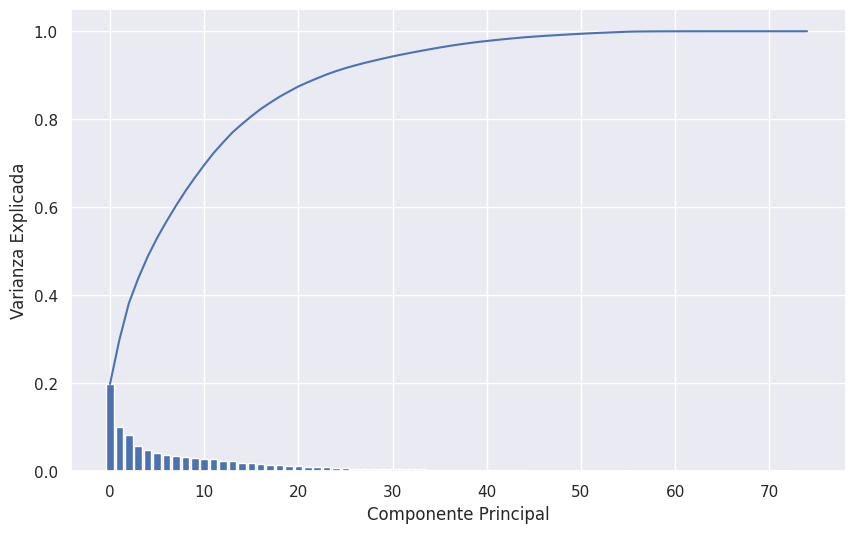

In [ ]:
num_components = len(pca.explained_variance_ratio_) #almacena el número total de componentes principales generados por el modelo PCA
plt.figure(figsize=(10, 6))
plt.bar(np.arange(num_components), pca.explained_variance_ratio_)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Componente Principal')
plt.ylabel('Varianza Explicada')
plt.show()

In [ ]:
pca = PCA(n_components=0.80)
pca.fit(X_norm[:train_end_idx])
X_pca = pca.transform(X_norm)

 utiliza el Análisis de Componentes Principales **(PCA)** para reducir la dimensionalidad del conjunto de **datos X_norm**, seleccionando el número de componentes principales de tal manera que se explique al menos el 80% de la varianza total de los datos.

 Es una forma de decidir cuántos componentes principales retener basándose en la cantidad de información (varianza) que queremos preservar.

In [ ]:
X_pca.shape

(35064, 16)

In [ ]:
dataset_norm = np.concatenate((X_pca, y_norm), axis=1)

past_history = 24
future_target = 0

In [ ]:
X_train, y_train = multivariate_data(dataset_norm, dataset_norm[:, -1],
                                     0, train_end_idx, past_history,
                                     future_target, step=1, single_step=True)

In [ ]:
X_val, y_val = multivariate_data(dataset_norm, dataset_norm[:, -1],
                                 train_end_idx, cv_end_idx, past_history,
                                 future_target, step=1, single_step=True)

In [ ]:
X_test, y_test = multivariate_data(dataset_norm, dataset_norm[:, -1],
                                   cv_end_idx, test_end_idx, past_history,
                                   future_target, step=1, single_step=True)

In [ ]:
batch_size = 32
buffer_size = 1000

In [ ]:
train = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train = train.cache().shuffle(buffer_size).batch(batch_size).prefetch(1)

validation = tf.data.Dataset.from_tensor_slices((X_val, y_val))
validation = validation.batch(batch_size).prefetch(1)

In [ ]:
# Definir algunos parametros comunes

input_shape = X_train.shape[-2:]
loss = tf.keras.losses.MeanSquaredError()
metric = [tf.keras.metrics.RootMeanSquaredError()]
lr_schedule = tf.keras.callbacks.LearningRateScheduler(
              lambda epoch: 1e-4 * 10**(epoch / 10))
early_stopping = tf.keras.callbacks.EarlyStopping(patience=10)

In [ ]:
y_test = y_test.reshape(-1, 1)
y_test_inv = scaler_y.inverse_transform(y_test)

# **4. PRONOSTICO DEL PRECIO DE LA ENERGIA ELECTRICA**

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(16, input_shape=input_shape),  # Asegúrate de definir input_shape correctamente
    tf.keras.layers.Dense(1, activation='linear')  # Capa de salida para regresión
])
model.compile(optimizer='adam', loss=loss, metrics=metric)
history = model.fit(train, epochs=10, validation_data=validation, callbacks=[early_stopping])


Epoch 1/10
845/845 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0819 - root_mean_squared_error: 0.2651 - val_loss: 0.0104 - val_root_mean_squared_error: 0.1018
Epoch 2/10
845/845 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0146 - root_mean_squared_error: 0.1202 - val_loss: 0.0110 - val_root_mean_squared_error: 0.1050
Epoch 3/10
845/845 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0143 - root_mean_squared_error: 0.1191 - val_loss: 0.0119 - val_root_mean_squared_error: 0.1092
Epoch 4/10
845/845 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0143 - root_mean_squared_error: 0.1189 - val_loss: 0.0118 - val_root_mean_squared_error: 0.1085
Epoch 5/10
845/845 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0144 - root_mean_squared_error: 0.1193 - val_loss: 0.0116 - val_root_mean_squared_error: 0.1078
Epoch 6/10
845/845 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0145 - root_mean_squared_error: 0.1195 - val_loss: 0.0121 - val_root_mean_squared_error: 0.1102
Epoch 7/10
845/845 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step 

In [ ]:
def plot_model_rmse_and_loss(history):
    # Evaluate train and validation accuracies and losses
    train_rmse = history.history['root_mean_squared_error']
    val_rmse = history.history['val_root_mean_squared_error']
    train_loss = history.history['loss']
    val_loss = history.history['val_loss']

    # Visualize epochs vs. train and validation accuracies and losses
    plt.figure(figsize=(20, 10))
    plt.subplot(1, 2, 1)
    plt.plot(train_rmse, label='Training RMSE')
    plt.plot(val_rmse, label='Validation RMSE')
    plt.legend()
    plt.title('Epochs vs. Training and Validation RMSE')

    plt.subplot(1, 2, 2)
    plt.plot(train_loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.legend()
    plt.title('Epochs vs. Training and Validation Loss')

    plt.show()


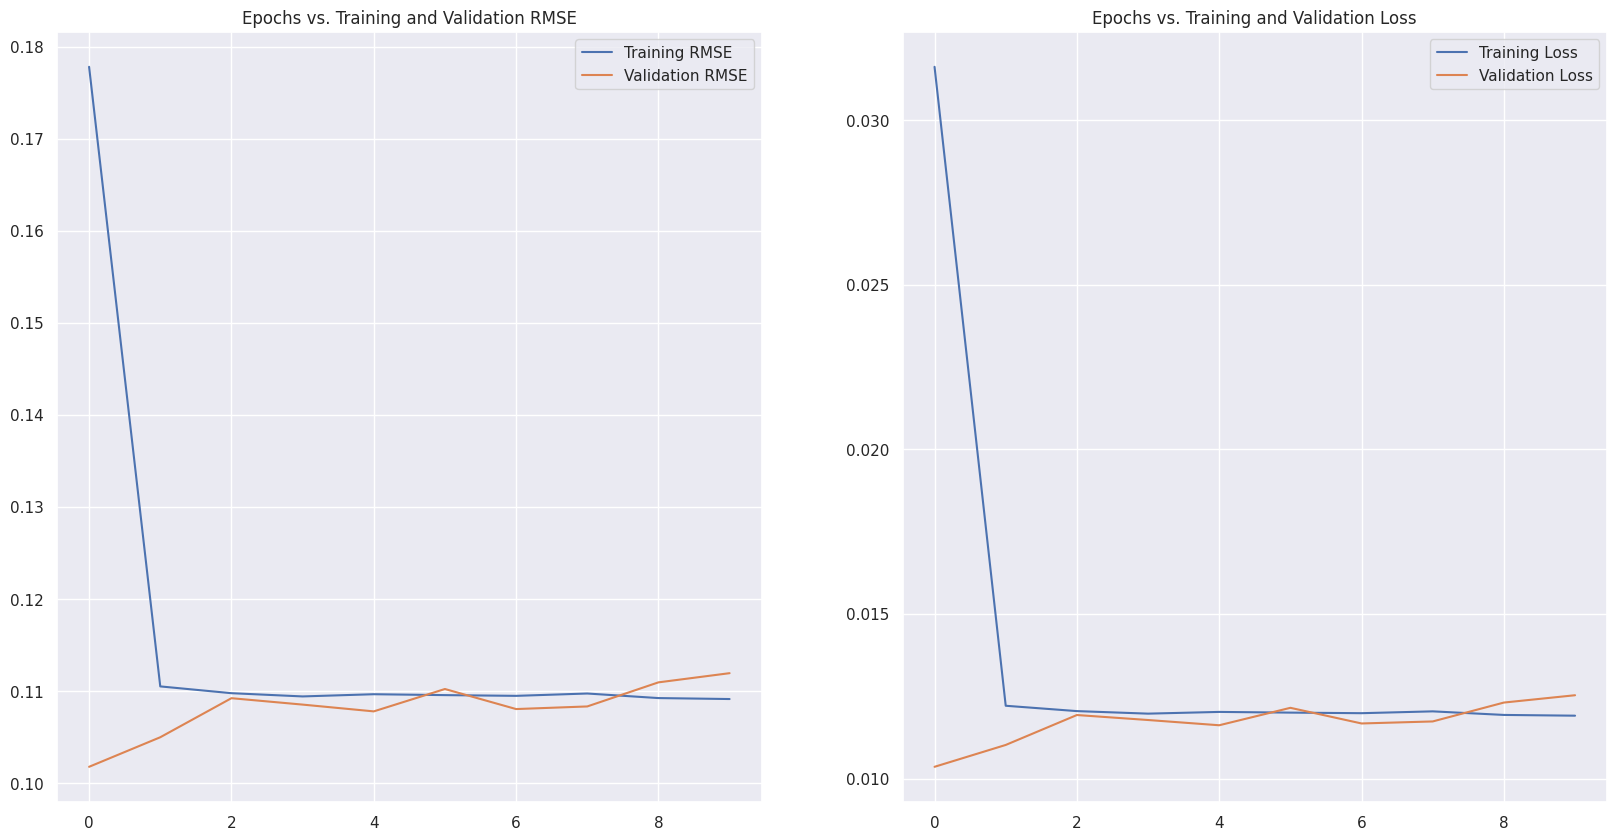

In [ ]:
plot_model_rmse_and_loss(history)

**HASTA AHORA CONSTRUIMOS UN DATASET PARA PRONOSTICAR EL PRECIO DE LA ENERGIA ELECTRICA EN 5 CIUDADES DEL PAIS, EL SIGUIENTE PASO ES USAR RNN PARA HACER DICHA PREDICCION.**


# **XGBoost**

#**LSTM OPTIMIZADO**


# **CODIGO LSTM (OPTIMIZADO)**

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import History
from tensorflow.keras.utils import plot_model

In [ ]:
print('X_train: ', X_train.shape)
print('y_train: ', y_train.shape)
print('-------')
print('X_test: ', X_test.shape)
print('y_test: ', y_test.shape)
print('-------')
print('X_val: ', X_val.shape)
print('y_val: ', y_val.shape)

X_train:  (27024, 24, 17)
y_train:  (27024,)
-------
X_test:  (3984, 24, 17)
y_test:  (3984, 1)
-------
X_val:  (3984, 24, 17)
y_val:  (3984,)


###**MODELO:** Sin Optimizar LSTM

In [ ]:
window_size = 24

In [ ]:
model1 = Sequential() # Secuencial significa que la Red Neuronal tiene varias capas
#model1.add(InputLayer((window_size, 1))) # Cual es el tamano de los datos de entrada
model1.add(InputLayer((window_size, 17))) # Cual es el tamano de los datos de entrada
model1.add(LSTM(64)) # Capa de tipo LSTM
model1.add(Dense(8, 'relu')) # Densa quiere decir que se conecten todas las neuronas y utilizamos una funcion de activacion tipo ReLu
model1.add(Dense(1, 'linear'))

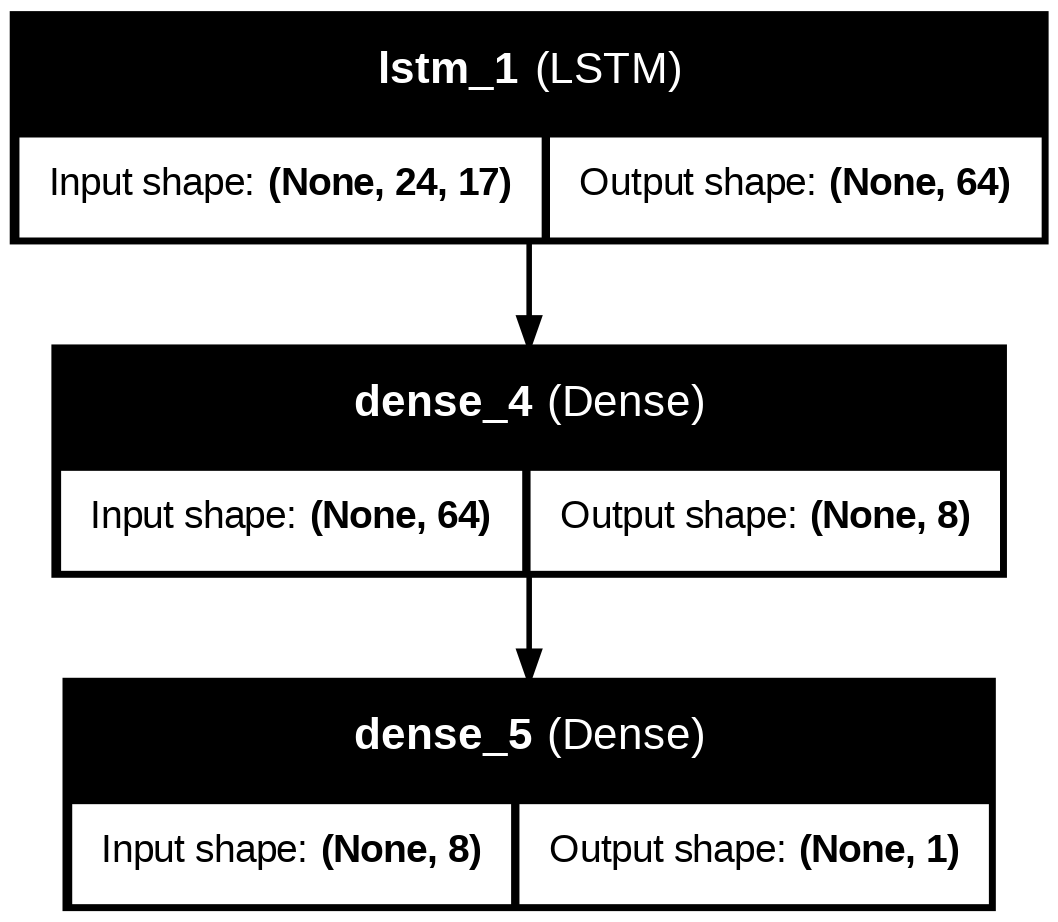

In [ ]:
# Guardar la visualización del modelo
plot_model(model1, to_file='rnn_model.png', show_shapes=True, show_layer_names=True)

In [ ]:
model1.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 64)                  │          20,992 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 8)                   │             520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 21,521 (84.07 KB)

 Trainable params: 21,521 (84.07 KB)

 Non-trainable params: 0 (0.00 B)

###**MODELO:** Optimizar LSTM

In [ ]:
!pip install tensorflow
import tensorflow as tf
import numpy as np
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN,LSTM, Dense, RNN, GRU
from tensorflow.keras.optimizers import Adam, SGD
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from IPython.display import SVG

!pip install keras-tuner
import keras_tuner as kt

from kerastuner.tuners import Hyperband
from kerastuner.engine.hyperparameters import HyperParameters

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 2.5 MB/s eta 0:00:00


<ipython-input-133-8db0c9f1ec08>:15: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  from kerastuner.tuners import Hyperband


In [ ]:
# Define un objeto HyperParameters
hp = HyperParameters()

In [ ]:
input_shape = X_train.shape[-2:]  # Toma las últimas dos dimensiones de X_train para definir la forma de entrada del modelo.


In [ ]:
def build_lstm_model(hp):
    #n_timesteps, n_features = X_train.shape[1], X_train.shape[2] # ELEGIR LOS HIPERPARAMETROS QUE NECESITEN OPTIMIZAR
    #n_outputs = 1  # Cambia esto si el número de salidas es diferente
    #n_layers = hp.Int('n_layers', min_value=1, max_value=10)

    modelop = Sequential()
    modelop.add(InputLayer((window_size, 17))) # Cual es el tamano de los datos de entrada


    modelop.add(LSTM(
        units=hp.Int('lstm_units', min_value=1, max_value=200, step=10),  # Número de unidades en la capa LSTM, ajustable entre 32 y 128 en pasos de 32
        input_shape=input_shape,  # La forma de los datos de entrada (debe ser definida antes de llamar a esta función)
        activation=hp.Choice('l_lstm_activation', values=['tanh', 'relu', 'sigmoid']),
        return_sequences=False  # Indica que esta capa LSTM devolverá solo la última salida en la secuencia de salida
    ))

    modelop.add(Dense(
        units=hp.Int('dense_units', min_value=1, max_value=200, step=10),  # Número de neuronas en la capa densa, ajustable entre 8 y 24 en pasos de 8
        activation=hp.Choice('l_dense_activation', values=['tanh', 'relu', 'sigmoid'])
    ))

    # Agregar otra capa densa que actuará como la capa de salida del modelo
    modelop.add(Dense(1, activation='linear'))  # Capa de salida para regresión, con activación lineal


    # Compilar el modelo
    modelop.compile(
        optimizer=Adam(hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')),  # Optimizador Adam con tasa de aprendizaje ajustable
        loss='mean_squared_error',  # Función de pérdida Mean Squared Error para problemas de regresión
        metrics=['RootMeanSquaredError']  # Métricas para evaluar el modelo durante el entrenamiento
    )

    return modelop  # Retornar el modelo compilado

In [ ]:
# Crea el sintonizador Hyperband
sintonizador = Hyperband(build_lstm_model, # PUEDEN USAR HYPERBAND O RAMDON SEARCH O BAYESIAN MODEL
                        objective="val_loss",  # Cambia a "val_loss"
                        max_epochs=10,
                        factor=3,
                        hyperband_iterations=5,
                        project_name='lstm_tuning')

In [ ]:
# Configurar el callback de parada temprana para prevenir el sobreajuste
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',  # Monitorear la pérdida de validación
    patience=3,  # Número de épocas sin mejora después de las cuales el entrenamiento se detendrá
    restore_best_weights=True  # Restaurar los pesos del mejor modelo encontrado
)
# Ejecutar la búsqueda de hiperparámetros
# 'train' es el conjunto de datos de entrenamiento y 'validation' es el conjunto de datos de validación,
# ambos preparados en pasos anteriores del proceso.
tuner.search(
    train,  # Datos de entrenamiento
    epochs=100,  # Número máximo de épocas para entrenar durante la búsqueda
    validation_data=validation,  # Datos de validación para evaluar los modelos
    callbacks=[early_stopping]  # Lista de callbacks, incluido el de parada temprana
)

In [ ]:
# Busca los mejores hiperparámetros
sintonizador.search(X_train, y_train, validation_split=0.2)

Trial 150 Complete [00h 01m 41s]
val_loss: 0.001559103955514729

Best val_loss So Far: 0.0005382481613196433
Total elapsed time: 04h 21m 19s


In [ ]:
# Obtiene la mejor configuración de hiperparámetros
best_hyperparameters = sintonizador.get_best_hyperparameters(num_trials=1)[0]

In [ ]:
# Imprimir los mejores hiperparámetros
for key, value in best_hyperparameters.values.items():
    print(f"{key}: {value}")

In [ ]:
# Construye y compila el modelo con los mejores hiperparámetros
best_model = build_lstm_model(best_hyperparameters)
best_model.compile(loss='mean_squared_error', optimizer=Adam(learning_rate=0.001))

In [ ]:
# Guarda la visualización del modelo
keras.utils.plot_model(best_model, to_file='best_model.png', show_shapes=True, show_layer_names=True)

###**MODELO:** FINAL LSTM + OPTIMIZADO

In [ ]:
window_size = 24

model1 = Sequential() # Secuencial significa que la Red Neuronal tiene varias capas
#model1.add(InputLayer((window_size, 1))) # Cual es el tamano de los datos de entrada
model1.add(InputLayer((window_size, 17))) # Cual es el tamano de los datos de entrada
model1.add(LSTM(131,'relu')) # Capa de tipo LSTM
model1.add(Dense(151, 'tanh')) # Densa quiere decir que se conecten todas las neuronas y utilizamos una funcion de activacion tipo ReLu
model1.add(Dense(1, 'linear'))

# Guardar la visualización del modelo
plot_model(model1, to_file='rnn_model.png', show_shapes=True, show_layer_names=True)

model1.summary()

### Compilación del modelo y entrenamiento:
Se compila el modelo definiendo la función de pérdida, el optimizador y las métricas. Luego se entrena el modelo utilizando los datos de entrenamiento y validación.

Les deseo poder realizar la mejor predicción a partir de la analita de datos + IA

In [ ]:
# Obtener historial de entrenamiento del modelo
history = History()

In [ ]:
# Aqui guardamos el modelo como un archivo independiente

#cp1 = ModelCheckpoint('/content/gdrive/MyDrive/IA Energias Renovables | UniAndes/Notebooks/Sesion 3b (Mar, 9, 2023)/model1/', save_best_only=True)
cp1 = ModelCheckpoint('/content/gdrive/MyDrive/Colab Notebooks/DIPLOMADO EPM/Datos/modelLSTM', save_best_only=True)

#model1.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.001), metrics=[RootMeanSquaredError()])
model1.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.005343634220268847), metrics=[RootMeanSquaredError()])

In [ ]:
# Parada temprana para evitar el sobreajuste.
# Detiene el entrenamiento si la métrica de validación no mejora después de un número definido de épocas ('patience').

#early_stopping = tf.keras.callbacks.EarlyStopping(patience=3)

In [ ]:
# Fit the model
with tf.device('/device:GPU:0'):  # Specify the GPU device to use
    history = model1.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, callbacks=[cp1]) # cp = check point

# model1 = load_model('/content/gdrive/MyDrive/IA Energias Renovables | UniAndes/Notebooks/Sesion 3a (Mar, 7, 2023)/model1/')

# model1.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, callbacks=[cp1])

#history = model.fit(train, epochs=100, validation_data=validation, callbacks=[early_stopping])

In [ ]:
# Plot the loss history
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Pérdida en función del número de épocas')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()


#SIN OPTIMIZAR 0.0006666666

### Carga del modelo guardado y predicción:
Finalmente, se carga el modelo guardado y se realizan las predicciones para los datos de entrenamiento, validación y prueba.

In [ ]:
# Cargamos modelo

#model1 = load_model('/content/gdrive/MyDrive/IA Energias Renovables | UniAndes/Notebooks/Sesion 3b (Mar, 9, 2023)/model1/')
model1 = load_model('/content/gdrive/MyDrive/Colab Notebooks/DIPLOMADO EPM/Datos/modelLSTM')

In [ ]:
train_predictions = model1.predict(X_train).flatten()
train_results = pd.DataFrame(data={'Train Predictions':train_predictions, 'Actuals':y_train})
train_results

In [ ]:
plt.figure(figsize = [10, 4])
plt.title('Train Results (Full)', fontsize = 14)
plt.plot(train_results['Train Predictions'], label = 'Prediccion')
plt.plot(train_results['Actuals'], label = 'Real')
plt.ylabel('PRICE ACTUAL')
plt.legend()

In [ ]:
plt.figure(figsize = [10, 4])
plt.title('Train Results', fontsize = 14)
plt.plot(train_results['Train Predictions'][50:100], label = 'Prediccion')
plt.plot(train_results['Actuals'][50:100], label = 'Real')
plt.ylabel('PRICE ACTUAL')
plt.legend()

In [ ]:
import numpy as np
import pandas as pd

# Asegúrate de que test_predictions y y_test sean arrays bidimensionales
test_predictions = model1.predict(X_test).flatten()
test_predictions = np.reshape(test_predictions, (-1, 1))

y_test = np.reshape(y_test, (-1, 1))

# Construye el DataFrame
test_results = pd.DataFrame(data={'Test Predictions': test_predictions.flatten(), 'Actuals': y_test.flatten()})

In [ ]:
plt.figure(figsize = [10, 4])
plt.title('Test Results (Full)', fontsize = 14)
plt.plot(test_results['Test Predictions'][50:100], label = 'Prediccion')
plt.plot(test_results['Actuals'][50:100], label = 'Real')
plt.ylabel('PRICE ACTUAL')
plt.legend()

In [ ]:
val_predictions = model1.predict(X_val).flatten()
val_results = pd.DataFrame(data={'Val Predictions':val_predictions, 'Actuals':y_val})
val_results

In [ ]:
plt.figure(figsize = [10, 4])
plt.title('Validation Results (Full)', fontsize = 14)
plt.plot(val_results['Val Predictions'], label = 'Prediccion')
plt.plot(val_results['Actuals'], label = 'Real')
plt.ylabel('PRICE ACTUAL')
plt.legend()

In [ ]:
plt.figure(figsize = [10, 4])
plt.title('Validation Results', fontsize = 14)
plt.plot(val_results['Val Predictions'][:100], label = 'Prediccion')
plt.plot(val_results['Actuals'][:100], label = 'Real')
plt.ylabel('PRICE ACTUAL')
plt.legend()

In [ ]:
# Calculate RMSE and MSE for train, validation and test datasets
train_loss, train_rmse = model1.evaluate(X_train, y_train, verbose=0)
val_loss, val_rmse = model1.evaluate(X_val, y_val, verbose=0)
test_loss, test_rmse = model1.evaluate(X_test, y_test, verbose=0)

In [ ]:
print(f'Train RMSE: {train_rmse:.2f}')
print(f'Train MSE: {train_loss:.2f}')
print(f'Validation RMSE: {val_rmse:.2f}')
print(f'Validation MSE: {val_loss:.2f}')
print(f'Test RMSE: {test_rmse:.2f}')
print(f'Test MSE: {test_loss:.2f}')

#Sin optimizar
#Train RMSE: 0.02
#Train MSE: 0.00
#Validation RMSE: 0.02
#Validation MSE: 0.00
#Test RMSE: 0.02
#Test MSE: 0.00

#Optimizado
#Train RMSE: 0.02
#Train MSE: 0.00
#Validation RMSE: 0.02
#Validation MSE: 0.00
#Test RMSE: 0.02
#Test MSE: 0.00


## Prediccion

Ahora podemos realizar la prediccion de las proximos 100 horas de velocidad de viento, utilizando el modelo:

In [ ]:
# Necesitamos preparar el conjunto de datos para los siguientes días a predecir
# Future_target: Número de días a predecir, ajusta 'past_history' según tu configuración

# 'future_target' para predecir 60 días
future_target = 60

# Genera un conjunto de datos de entrada para las predicciones

# Inicializa el conjunto de datos de predicción con los últimos datos disponibles
last_known_data = dataset_norm[-past_history:]

# Lista para almacenar las predicciones
predicted_prices = []

# Realiza predicciones para los siguientes días a predecir
for i in range(future_target):
    # Prepara los datos para el modelo
    X_predict = last_known_data.reshape((1, last_known_data.shape[0], last_known_data.shape[1]))

    # Realiza la predicción
    predicted_price = model1.predict(X_predict)

    # Añade la predicción a la lista de predicciones
    predicted_prices.append(predicted_price[0])

    # Actualiza 'last_known_data' para incluir la nueva predicción y eliminar el dato más antiguo
    last_known_data = np.roll(last_known_data, -1, axis=0)
    last_known_data[-1] = np.concatenate((last_known_data[-1, :-1], predicted_price[0]))

# Transforma las predicciones a su escala original
predicted_prices_scaled = scaler_y.inverse_transform(predicted_prices)

In [ ]:
#df_final.info()
df_final.index


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

def plot_predictions(df_actual, predicted_prices_scaled, future_target):
    last_real_date = df_actual.index[-1]
    prediction_dates = pd.date_range(start=last_real_date + pd.Timedelta(days=1), periods=future_target)

    plt.style.use('dark_background')  # Cambia el fondo a negro

    plt.figure(figsize=(28, 10))

    # Datos Reales
    plt.plot(df_actual.index, df_actual['price actual'], label='Datos Reales', color='green', marker='o', linestyle='-', linewidth=2)

    # Predicciones
    plt.plot(prediction_dates, predicted_prices_scaled, label='Predicciones', color='orange', marker='x', linestyle='-', linewidth=2)

    # Personalización del gráfico
    plt.title('Predicción de Precio vs Datos Reales', fontsize=16, color='white')
    plt.xlabel('Fecha', fontsize=14, color='white')
    plt.ylabel('Precio', fontsize=14, color='white')
    plt.legend(fontsize=12)

    plt.xticks(rotation=0, fontsize=12, color='white')
    plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=90))  # Una división por día
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  # Formato de fech

    plt.yticks(fontsize=12, color='white')

    plt.grid(True, linestyle='--', alpha=0.7)

    # Añadir una línea vertical para separar los datos reales de las predicciones
    plt.axvline(x=last_real_date, color='red', linestyle='--', linewidth=2, label='Fin Datos Reales')

    # Establecer los límites del eje x para centrarse en los datos después de 2018
    #plt.xlim(pd.to_datetime('2018-01-01'), None)

    plt.show()

# Uso de la función
plot_predictions(df_final, predicted_prices_scaled, future_target)